<a href="https://colab.research.google.com/github/gorchimi/HW_Pandas_Review/blob/main/673020491_6_Pandas_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**นางสาว ธิติสุดา แดงสีดา รหัสนักศึกษา 673020491-6**

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

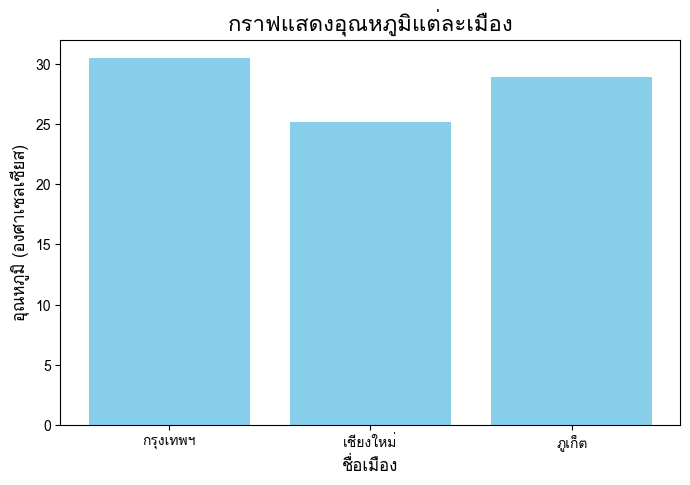

In [1]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [2]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [3]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


s["a"] และ s.iloc[0] คืนค่าเป็นสเกลาร์ (Scalar/Scalar type เช่น np.int64 หรือ int) โดย s["a"] อ้างอิงผ่าน Index Label ส่วน s.iloc[0] อ้างอิงผ่านตำแหน่งลำดับ (Positional Index)

s[["a", "c"]] คืนค่าเป็น pd.Series (Data Structure ขนาด 1 มิติ) เนื่องจากรับ Input เป็น List ของ Label ทำให้ได้ข้อมูลเป็นตระกูล Series ที่ย่อยออกมา

In [4]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


df["city"] คืนค่าเป็น pd.Series รูปร่าง (N,) เหมาะสำหรับนำไปคำนวณเชิงเวกเตอร์ (Vectorized Operations) หรือดึงข้อมูลคอลัมน์เดียวไปใช้งาน

df[["city"]] คืนค่าเป็น pd.DataFrame รูปร่าง (N, 1) เหมาะสำหรับการทำ Operations ที่ต้องการโครงสร้าง 2 มิติ เช่น การ Merge, Join หรือส่งต่อให้ ฟังก์ชั่นที่รองรับเฉพาะ DataFrame

In [5]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


df.loc[0:3] ใช้ Label-based indexing ซึ่งการ Slice ด้วย loc จะนับรวมจุดสิ้นสุด (Inclusive) ดังนั้นจึงคืนค่าแถวที่มี Label 0, 1, 2, 3 รวมเป็น 4 แถว

df.iloc[0:3] ใช้ Position-based indexing ซึ่งการ Slice ด้วย iloc จะไม่นับรวมจุดสิ้นสุด (Exclusive) เหมือนการ Slice ใน Python List ตามปกติ จึงคืนค่าแถวที่ตำแหน่ง 0, 1, 2 รวมเป็น 3 แถว

In [6]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


.count() นับเฉพาะจำนวนข้อมูลที่ไม่เป็นค่าว่าง (Non-null values) ในคอลัมน์นั้นๆ

.size() นับจำนวนแถวทั้งหมดในแต่ละกลุ่ม โดยรวมค่าว่าง (Null / NaN) ด้วย

สถานการณ์ที่เลือกใช้: ใช้ .count() เมื่อต้องการทราบจำนวนข้อมูลที่สมบูรณ์จริง และใช้ .size() เมื่อต้องการทราบจำนวน Record หรือขนาดของตัวอย่างในกลุ่มนั้นๆ ทั้งหมด

In [7]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


การใช้ซ้อนวงเล็บกวาดกลม ["temperature_c"] จะคืนผลลัพธ์เป็น pd.Series ที่มี Index เป็นชื่อเมือง

การใช้ซ้อนวงเล็บเหลี่ยมสองชั้น [["temperature_c"]] จะคืนผลลัพธ์เป็น pd.DataFrame ที่มี 1 คอลัมน์

การเลือกใช้: เลือกใช้แบบ Series เมื่อต้องการนำผลลัพธ์ไปประมวลผลต่อกับ Series อื่นๆ หรือใช้เป็น Map/Filter สเกลาร์ ส่วนแบบ DataFrame เหมาะสำหรับการส่งออกไฟล์รายงาน หรือทำ chaining methods ที่ใช้กับ DataFrame

In [8]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


a + b ทำงานตามหลักการ Index Alignment ของ pandas โดยจับคู่บวกเฉพาะ Index ที่ชื่อเหมือนกัน ส่วน Index ที่ไม่ตรงกันจะคืนค่าเป็น NaN (ได้ Index เป็น a, b, c, d)

a.to_numpy() + b.to_numpy() แปลง Series เป็น NumPy Array แล้วทำการบวกกันด้วย Positional Alignment (จับคู่ตามลำดับตำแหน่ง 0, 1, 2) โดยละทิ้งข้อมูล Index ไปเลย ผลลัพธ์จึงเป็น Array ขนาด 3 สมาชิก [1+4, 2+5, 3+6] = [5, 7, 9]

---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [9]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [10]:
# คำตอบข้อ 2.1
# คำนวณฝนรวมรายเมืองโดยใช้ Vectorized Operation (Groupby)
rain_by_city = df.groupby("city")["rainfall_mm"].sum()

# 1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
top3_rain = rain_by_city.nlargest(3)
print("1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก (mm):")
print(top3_rain)

# 2. สัดส่วนปริมาณฝนเทียบกับฝนรวมทั้งหมด (%) คำนวณแบบ Vectorized
rain_pct = (rain_by_city / rain_by_city.sum() * 100).round(2)
print("\n2. ตัวอย่างสัดส่วนปริมาณฝนของแต่ละเมือง (%):")
print(rain_pct.head())

# 3. เมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย
mean_rain_val = rain_by_city.mean()
above_avg_mask = rain_by_city > mean_rain_val
above_avg_count = above_avg_mask.sum()

print(f"\n3. ปริมาณฝนรวมเฉลี่ยทุกเมือง = {mean_rain_val:.2f} mm")
print(f"   จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย: {above_avg_count} เมือง")

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก (mm):
city
Singapore    870.4
Bangkok      685.6
Lagos        652.8
Name: rainfall_mm, dtype: float64

2. ตัวอย่างสัดส่วนปริมาณฝนของแต่ละเมือง (%):
city
Auckland        4.22
Bangkok         8.21
Beijing         3.00
Berlin          3.21
Buenos Aires    3.65
Name: rainfall_mm, dtype: float64

3. ปริมาณฝนรวมเฉลี่ยทุกเมือง = 362.97 mm
   จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย: 8 เมือง


### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [11]:
# คำตอบข้อ 2.2
city_profile = df.groupby("city", as_index=False).agg(
    country=("country", "first"),
    region=("region", "first"),
    n_records=("record_id", "count"),
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum")
)

# จัดเรียงลำดับตาม total_rain จากมากไปน้อย
city_profile = city_profile.sort_values(by="total_rain", ascending=False).reset_index(drop=True)

print("รูปร่าง DataFrame (Shape):", city_profile.shape)
city_profile.head()


รูปร่าง DataFrame (Shape): (23, 6)


,city,country,region,n_records,avg_temp,total_rain
0,Singapore,Singapore,Asia,90,40.083333,870.4
1,Bangkok,Thailand,Asia,91,32.453846,685.6
2,Lagos,Nigeria,Africa,90,29.494253,652.8
3,Mumbai,India,Asia,90,30.872222,487.9
4,Chiang Mai,Thailand,Asia,91,29.680220,435.6


---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [12]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [13]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [14]:
# คำตอบข้อ 3.1
df_custom = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={"city": "category", "region": "category"},
    index_col="city"
)

print("ชนิดข้อมูลของแต่ละคอลัมน์:")
print(df_custom.dtypes)
print("-" * 50)
df_custom.info()


ชนิดข้อมูลของแต่ละคอลัมน์:
date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [15]:
# คำตอบข้อ 3.2
mem_normal = df.memory_usage(deep=True).sum()
mem_custom = df_custom.memory_usage(deep=True).sum()
reduction_pct = ((mem_normal - mem_custom) / mem_normal) * 100

print(f"หน่วยความจำของการโหลดปกติ: {mem_normal / 1024:.2f} KB")
print(f"หน่วยความจำของการโหลดแบบปรับแต่ง: {mem_custom / 1024:.2f} KB")
print(f"ปริมาณหน่วยความจำที่ลดลง: {reduction_pct:.2f}%")


หน่วยความจำของการโหลดปกติ: 558.25 KB
หน่วยความจำของการโหลดแบบปรับแต่ง: 71.21 KB
ปริมาณหน่วยความจำที่ลดลง: 87.24%


คอลัมน์ city และ region มีผลต่อการลดลงของหน่วยความจำมากที่สุด เพราะการเปลี่ยนจากชนิดข้อมูล object (string) เป็น category ช่วยลดการเก็บข้อความซ้ำๆ ในทุกแถว โดยเปลี่ยนเป็นการเก็บรหัสตัวเลขขนาดเล็กแทน

### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [125]:
# คำตอบข้อ 3.3
min_temp = float('inf')
max_temp = float('-inf')

city_stats = {}

for chunk in pd.read_csv(BASE + "world_weather_sample.csv", na_values=[999, -999], chunksize=500):
    # หา min / max
    chunk_min = chunk["temperature_c"].min()
    chunk_max = chunk["temperature_c"].max()
    if chunk_min < min_temp: min_temp = chunk_min
    if chunk_max > max_temp: max_temp = chunk_max

    # สะสมค่าสำหรับหาอุณหภูมิเฉลี่ยรายเมือง
    for city, group in chunk.groupby("city"):
        valid_temps = group["temperature_c"].dropna()
        if city not in city_stats:
            city_stats[city] = {"sum": 0.0, "count": 0}
        city_stats[city]["sum"] += valid_temps.sum()
        city_stats[city]["count"] += valid_temps.count()

avg_temp_by_city = pd.Series({city: stats["sum"] / stats["count"] for city, stats in city_stats.items()})

print(f"อุณหภูมิต่ำสุดทั้งไฟล์: {min_temp}")
print(f"อุณหภูมิสูงสุดทั้งไฟล์: {max_temp}")
print("\nอุณหภูมิเฉลี่ยรายเมือง (ตัวอย่าง 5 เมืองแรก):")
print(avg_temp_by_city.head())

อุณหภูมิต่ำสุดทั้งไฟล์: -88.0
อุณหภูมิสูงสุดทั้งไฟล์: 39.2

อุณหภูมิเฉลี่ยรายเมือง (ตัวอย่าง 5 เมืองแรก):
Auckland        17.804444
Bangkok         32.453846
Beijing         15.598876
Berlin          12.383146
Buenos Aires    19.171910
dtype: float64


การนำค่าเฉลี่ยของแต่ละก้อน (chunk) มาเฉลี่ยกันอีกครั้งจะให้ผลลัพธ์ไม่ถูกต้องเนื่องจากจำนวนข้อมูลที่สมบูรณ์ (count) ในแต่ละ chunk อาจมีไม่เท่ากัน (Weighted Average) สิ่งที่ถูกต้องคือต้องสะสม ผลรวม (Sum) และ จำนวนข้อมูลจริง (Count) แยกกัน แล้วนำมาหารกันในขั้นตอนสุดท้าย

---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [20]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [21]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [22]:
# คำตอบข้อ 4.1
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().sum() / len(df) * 100).round(2),
    'n_unique': df.nunique(),
    'example_value': df.iloc[0]
}).sort_values(by='n_missing', ascending=False)

summary

,dtype,n_missing,pct_missing,n_unique,example_value
humidity_pct,float64,82,3.95,544,72.6
rainfall_mm,float64,62,2.99,164,6.3
wind_speed_kmh,float64,41,1.98,278,15.9
pressure_hpa,float64,32,1.54,294,1005.4
temperature_c,float64,20,0.96,331,15.7
record_id,int64,0,0.00,2070,983
date,object,0,0.00,90,2025-03-24
region,object,0,0.00,6,North America
city,object,0,0.00,23,New York
country,object,0,0.00,28,USA


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [23]:
# คำตอบข้อ 4.2
# สร้าง Mask แบบ Vectorized
invalid_temp = (df["temperature_c"] < -60) | (df["temperature_c"] > 60)
invalid_humid = (df["humidity_pct"] < 0) | (df["humidity_pct"] > 100)

cnt_invalid_temp = invalid_temp.sum()
cnt_invalid_humid = invalid_humid.sum()
cnt_any_invalid = (invalid_temp | invalid_humid).sum()

print(f"1. จำนวนแถวที่ temperature_c อยู่นอกช่วง [-60, 60]: {cnt_invalid_temp} แถว")
print(f"2. จำนวนแถวที่ humidity_pct อยู่นอกช่วง [0, 100]: {cnt_invalid_humid} แถว")
print(f"3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์: {cnt_any_invalid} แถว")

1. จำนวนแถวที่ temperature_c อยู่นอกช่วง [-60, 60]: 5 แถว
2. จำนวนแถวที่ humidity_pct อยู่นอกช่วง [0, 100]: 3 แถว
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์: 8 แถว


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [24]:
# คำตอบข้อ 4.3
print("ค่า country ที่พบก่อน Cleanup:")
print(df["country"].unique())

# การทำความสะอาดข้อมูลแบบ Vectorized String Operations
clean_country = df["country"].astype(str).str.strip().str.upper()

print("\nค่า country หลังทำความสะอาด:")
print(clean_country.unique())
print(f"\nจำนวนประเทศที่ไม่ซ้ำกันหลังทำความสะอาด: {clean_country.nunique()} ประเทศ")

ค่า country ที่พบก่อน Cleanup:
['USA' 'Japan' 'India' 'South Africa' 'New Zealand' 'Argentina' 'Mexico'
 'Russia' 'Kenya' 'China' 'Australia' 'Nigeria' 'Peru' 'France'
 'Singapore' 'Egypt' 'UK' 'Thailand' 'Germany' 'Brazil' 'Canada' 'GERMANY'
 'CANADA' 'SINGAPORE' 'NEW ZEALAND' 'ARGENTINA' 'JAPAN' 'KENYA']

ค่า country หลังทำความสะอาด:
['USA' 'JAPAN' 'INDIA' 'SOUTH AFRICA' 'NEW ZEALAND' 'ARGENTINA' 'MEXICO'
 'RUSSIA' 'KENYA' 'CHINA' 'AUSTRALIA' 'NIGERIA' 'PERU' 'FRANCE'
 'SINGAPORE' 'EGYPT' 'UK' 'THAILAND' 'GERMANY' 'BRAZIL' 'CANADA']

จำนวนประเทศที่ไม่ซ้ำกันหลังทำความสะอาด: 21 ประเทศ


การใช้ .str.title() จะทำให้ชื่อประเทศบางประเทศผิดพลาด เช่น "USA" จะกลายเป็น "Usa" หรือ "UK" จะกลายเป็น "Uk" ซึ่งไม่ตรงตามมาตรฐานการเขียนชื่อตัวย่อประเทศ วิธีที่ถูกต้องคือใช้ .str.strip() เพื่อลบช่องว่างหัวท้าย และ .str.upper() หรือ Map ด้วยพจนานุกรมค่ามาตรฐาน

---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [25]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [26]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 8)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [27]:
# คำตอบข้อ 5.1
# 1. เลือกแถวคู่ (Even Index) 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
res_1 = df.iloc[0:20:2, -3:]
print("1. แถวคู่ 10 แถวแรก เฉพาะ 3 คอลัมน์สุดท้าย:")
print(res_1)

# 2. เลือกห้าแถวสุดท้าย เรียงจากล่างขึ้นบน
res_2 = df.iloc[-1:-6:-1]
print("\n2. ห้าแถวสุดท้าย เรียงจากล่างขึ้นบน:")
print(res_2)

# 3. เลือกเฉพาะค่าในคอลัมน์สุดท้าย ของแถวที่อยู่ตรงกลาง
mid_idx = len(df) // 2
res_3 = df.iloc[mid_idx, -1]
print(f"\n3. ค่าในคอลัมน์สุดท้าย ของแถวตรงกลาง (Row index = {mid_idx}): {res_3}")

1. แถวคู่ 10 แถวแรก เฉพาะ 3 คอลัมน์สุดท้าย:
    rainfall_mm  wind_speed_kmh  pressure_hpa
0           6.3            15.9        1005.4
2           1.2             8.6        1013.5
4           0.0            16.6        1015.1
6           2.7            14.6        1018.0
8           1.6             9.8        1007.7
10          0.0            15.6        1010.1
12          0.0            13.6        1015.8
14          2.2            24.6        1000.5
16          8.3             9.3        1019.4
18          8.9            23.3        1020.6

2. ห้าแถวสุดท้าย เรียงจากล่างขึ้นบน:
      record_id        date         city country         region  \
2074        642  2025-01-12        Paris  France         Europe   
2073       1210  2025-02-09      Toronto  Canada  North America   
2072       1738  2025-01-28      Nairobi   Kenya         Africa   
2071       1769  2025-02-28      Nairobi   Kenya         Africa   
2070       1093  2025-01-13  Mexico City  Mexico  North America   

      tem

### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [28]:
# คำตอบข้อ 5.2
# สร้าง MultiIndex และเรียง Index เพื่อประสิทธิภาพสูงสุด
df_multi = df.set_index(["region", "city"]).sort_index()

# 1. เลือกข้อมูลของภูมิภาค Asia เฉพาะคอลัมน์ date และ temperature_c
res_asia = df_multi.loc["Asia", ["date", "temperature_c"]]
print("1. ตัวอย่างข้อมูลภูมิภาค Asia:")
print(res_asia.head())

# 2. เลือกข้อมูลของเมือง Tokyo และ Bangkok
res_tokyo_bkk = df_multi.loc[(slice(None), ["Tokyo", "Bangkok"]), :]
print("\n2. ตัวอย่างข้อมูลเมือง Tokyo และ Bangkok:")
print(res_tokyo_bkk.head())

# 3. เลือกข้อมูลของเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B
b_cities = [c for c in df_multi.index.get_level_values("city").unique() if str(c).startswith("B")]
res_b_cities = df_multi.loc[(slice(None), b_cities), :]
print("\n3. ตัวอย่างข้อมูลเมืองที่ขึ้นต้นด้วย B:")
print(res_b_cities.head())

1. ตัวอย่างข้อมูลภูมิภาค Asia:
               date  temperature_c
city                              
Bangkok  2025-02-22           30.8
Bangkok  2025-01-10           28.9
Bangkok  2025-01-27           27.9
Bangkok  2025-01-03           29.0
Bangkok  2025-03-28           31.0

2. ตัวอย่างข้อมูลเมือง Tokyo และ Bangkok:
              record_id        date country  temperature_c  humidity_pct  \
region city                                                                
Asia   Tokyo        220  2025-02-09   Japan           18.3          60.6   
       Tokyo        260  2025-03-21   Japan           19.7          67.4   
       Tokyo        262  2025-03-23   Japan           17.7          60.2   
       Tokyo        203  2025-01-23   Japan           20.8          61.6   
       Tokyo        218  2025-02-07   Japan           19.5          68.2   

              rainfall_mm  wind_speed_kmh  pressure_hpa  
region city                                              
Asia   Tokyo          0.0       

เหตุผลการใช้ .sort_index(): มีความสำคัญอย่างยิ่งเนื่องจาก pandas จะสามารถค้นหาข้อมูลผ่านโครงสร้าง B-Tree ได้ในระดับความเร็ว $O(\log N)$ และช่วยป้องกันความผิดพลาดประเภท UnsortedIndexError เมื่อต้อง slicing หรือกรองข้อมูลใน MultiIndex หลายระดับ

### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [29]:
# คำตอบข้อ 5.3
# รูปแบบที่ 1: ต้องการแก้ไขค่าใน DataFrame เดิมโดยตรง (ใช้ .loc)
df.loc[df["city"] == "Bangkok", "temperature_c"] = 0

# รูปแบบที่ 2: ต้องการคัดลอกข้อมูลออกมาเป็นตารางใหม่ไปใช้งาน (ใช้ .copy())
df_bangkok = df[df["city"] == "Bangkok"].copy()
df_bangkok["temperature_c"] = 0

---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [30]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

176
1894
740
295


In [31]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [32]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [33]:
# คำตอบข้อ 6.1
# 1. region เป็น Asia, rainfall_mm > 5, wind_speed_kmh > 20
cond1 = df[(df["region"] == "Asia") & (df["rainfall_mm"] > 5) & (df["wind_speed_kmh"] > 20)]
print(f"1. จำนวนแถวตามเงื่อนไขที่ 1: {len(cond1)} แถว")

# 2. city ไม่ใช่ Bangkok, Tokyo, London และ humidity_pct อยู่ระหว่าง 40 ถึง 60
cond2 = df[(~df["city"].isin(["Bangkok", "Tokyo", "London"])) & (df["humidity_pct"].between(40, 60))]
print(f"2. จำนวนแถวตามเงื่อนไขที่ 2: {len(cond2)} แถว")

# 3. มีค่า missing value ในแถวนั้นตั้งแต่ 2 คอลัมน์ขึ้นไป
cond3 = df[df.isna().sum(axis=1) >= 2]
print(f"3. จำนวนแถวตามเงื่อนไขที่ 3: {len(cond3)} แถว")

# 4. city มีคำว่า New หรือ San
cond4 = df[df["city"].astype(str).str.contains(r"New|San", regex=True, na=False)]
print(f"4. จำนวนแถวตามเงื่อนไขที่ 4: {len(cond4)} แถว")

1. จำนวนแถวตามเงื่อนไขที่ 1: 54 แถว
2. จำนวนแถวตามเงื่อนไขที่ 2: 470 แถว
3. จำนวนแถวตามเงื่อนไขที่ 3: 8 แถว
4. จำนวนแถวตามเงื่อนไขที่ 4: 90 แถว


### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [34]:
# คำตอบข้อ 6.2
# คำนวณค่า Percentile ที่ 99 แบบ Vectorized
p99_rain = df["rainfall_mm"].quantile(0.99)

# สร้างคอลัมน์ใหม่โดยใช้ .where และ .mask
df["temp_clean"] = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
df["rain_capped"] = df["rainfall_mm"].mask(df["rainfall_mm"] > p99_rain, p99_rain)

print(f"ค่า Percentile ที่ 99 ของ rainfall_mm: {p99_rain:.2f}")
df[["temperature_c", "temp_clean", "rainfall_mm", "rain_capped"]].head()


ค่า Percentile ที่ 99 ของ rainfall_mm: 14.69


,temperature_c,temp_clean,rainfall_mm,rain_capped
0,15.7,15.7,6.3,6.3
1,18.3,18.3,0.0,0.0
2,20.6,20.6,1.2,1.2
3,31.0,31.0,8.0,8.0
4,19.1,19.1,0.0,0.0


การใช้ .where() หรือ .mask() เหมาะสำหรับการทำความสะอาดและจัดการค่าผิดปกติ (Data Imputation / Outlier Capping) โดยที่ไม่เสียจำนวนแถวของข้อมูลเดิม ซึ่งเหมาะสำหรับการวิเคราะห์สถิติหรือสร้างโมเดล ในขณะที่การกรองแถวทิ้ง (Row Dropping) จะทำให้จำนวน Sample ลดลงและอาจเสียข้อมูลในคอลัมน์อื่นของแถวนั้นไปโดยไม่จำเป็น

### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [35]:
# คำตอบข้อ 6.3
df_valid_temp = df.dropna(subset=["temperature_c"]).copy()

# คำนวณค่าเฉลี่ยอุณหภูมิรายเมืองแล้วนำมาขยายกลับด้วย transform (Vectorized)
df_valid_temp["city_mean_temp"] = df_valid_temp.groupby("city")["temperature_c"].transform("mean")
df_valid_temp["temp_dev"] = (df_valid_temp["temperature_c"] - df_valid_temp["city_mean_temp"]).abs()

# หา Index ของค่าเบี่ยงเบนสูงสุดในแต่ละเมือง
max_dev_idx = df_valid_temp.groupby("city")["temp_dev"].idxmax()
result_6_3 = df_valid_temp.loc[max_dev_idx, ["city", "date", "temperature_c", "city_mean_temp", "temp_dev"]]

result_6_3.head()

,city,date,temperature_c,city_mean_temp,temp_dev
1036,Auckland,2025-02-27,25.6,17.804444,7.795556
67,Bangkok,2025-02-22,0.0,0.000000,0.000000
1778,Beijing,2025-03-06,22.6,15.598876,7.001124
1224,Berlin,2025-03-26,19.4,12.383146,7.016854
1280,Buenos Aires,2025-01-19,-88.0,19.171910,107.171910


---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [36]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [37]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    0.0
2025-01-08    0.0
2025-01-15    0.0
2025-01-22    0.0
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [38]:
# คำตอบข้อ 7.1
# แปลงเป็น datetime
df["date"] = pd.to_datetime(df["date"])

# สร้างคอลัมน์สกัดจาก datetime แบบ Vectorized
df["year_month"] = df["date"].dt.to_period("M").astype(str)
df["week_of_year"] = df["date"].dt.isocalendar().week
df["day_name"] = df["date"].dt.day_name()
df["is_weekend"] = df["date"].dt.dayofweek >= 5

df[["date", "year_month", "week_of_year", "day_name", "is_weekend"]].head()

,date,year_month,week_of_year,day_name,is_weekend
0,2025-03-24,2025-03,13,Monday,False
1,2025-02-09,2025-02,6,Sunday,True
2,2025-02-01,2025-02,5,Saturday,True
3,2025-01-19,2025-01,3,Sunday,True
4,2025-02-03,2025-02,6,Monday,False


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [39]:
# คำตอบข้อ 7.2
# 1. ตรวจสอบวันที่หายไป
all_dates = pd.date_range(start=df["date"].min(), end=df["date"].max())
missing_dates = all_dates.difference(df["date"])
print(f"1. ข้อมูลครอบคลุมทั้งหมด {len(all_dates)} วัน, มีวันที่ไม่มีข้อมูลเลย: {len(missing_dates)} วัน")

# 2. เปรียบเทียบอุณหภูมิเฉลี่ยวันหยุด vs วันธรรมดา จำแนกตามภูมิภาค
weekend_temp_comp = df.groupby(["region", "is_weekend"])["temperature_c"].mean().unstack()
weekend_temp_comp.columns = ["Weekday_Mean", "Weekend_Mean"]
print("\n2. การเปรียบเทียบอุณหภูมิเฉลี่ยวันธรรมดา vs วันหยุด:")
print(weekend_temp_comp.round(2))

# 3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง
monthly_rain = df.groupby(["city", "year_month"], as_index=False)["rainfall_mm"].sum()
max_rain_idx = monthly_rain.groupby("city")["rainfall_mm"].idxmax()
max_rain_months = monthly_rain.loc[max_rain_idx].reset_index(drop=True)

print("\n3. ตัวอย่างเดือนที่มีปริมาณฝนรวมสูงสุดรายเมือง:")
print(max_rain_months.head())

1. ข้อมูลครอบคลุมทั้งหมด 90 วัน, มีวันที่ไม่มีข้อมูลเลย: 0 วัน

2. การเปรียบเทียบอุณหภูมิเฉลี่ยวันธรรมดา vs วันหยุด:
               Weekday_Mean  Weekend_Mean
region                                   
Africa                27.94         23.88
Asia                  22.98         21.12
Europe                15.82         11.95
North America         16.72         16.84
Oceania               18.94         19.40
South America         21.70         19.84

3. ตัวอย่างเดือนที่มีปริมาณฝนรวมสูงสุดรายเมือง:
           city year_month  rainfall_mm
0      Auckland    2025-03        150.0
1       Bangkok    2025-02        243.9
2       Beijing    2025-02         87.4
3        Berlin    2025-03        100.1
4  Buenos Aires    2025-02        121.2


### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [40]:
# คำตอบข้อ 7.3
resampled_bkk = (
    df[df["city"] == "Bangkok"]
    .set_index("date")
    .resample("7D")
    .agg(
        avg_temp=("temperature_c", "mean"),
        total_rain=("rainfall_mm", "sum")
    )
    .round(2)
)

resampled_bkk.head()

,avg_temp,total_rain
date,,
2025-01-01,0.0,65.7
2025-01-08,0.0,47.6
2025-01-15,0.0,58.7
2025-01-22,0.0,50.0
2025-01-29,0.0,55.4


---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [41]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [42]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [43]:
# คำตอบข้อ 8.1
# 1. หาคอลัมน์ที่มี missing value มากที่สุด
null_counts = df.isna().sum()
max_null_col = null_counts.idxmax()
max_null_pct = (null_counts.max() / len(df)) * 100
print(f"1. คอลัมน์ที่มีค่าว่างมากที่สุด: {max_null_col} ({max_null_pct:.2f}%)")

# 2. สัดส่วน missing value ของ temperature_c รายเมือง
temp_null_by_city = df.groupby("city")["temperature_c"].apply(lambda s: (s.isna().sum() / len(s)) * 100).round(2)
print("\n2. ตัวอย่างสัดส่วนค่าว่างของ temperature_c รายเมือง (%):")
print(temp_null_by_city.head())

# 3. สัดส่วนข้อมูลที่เหลือหากใช้ dropna()
df_dropped = df.dropna()
remaining_pct = (len(df_dropped) / len(df)) * 100
print(f"\n3. สัดส่วนข้อมูลที่เหลือหาก dropna ทั้งหมด: {remaining_pct:.2f}%")

1. คอลัมน์ที่มีค่าว่างมากที่สุด: humidity_pct (3.95%)

2. ตัวอย่างสัดส่วนค่าว่างของ temperature_c รายเมือง (%):
city
Auckland        0.00
Bangkok         0.00
Beijing         1.11
Berlin          1.11
Buenos Aires    1.11
Name: temperature_c, dtype: float64

3. สัดส่วนข้อมูลที่เหลือหาก dropna ทั้งหมด: 88.72%


### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [44]:
# คำตอบข้อ 8.2
df_imp = df.copy()

# 1. เติมด้วยค่าเฉลี่ยรวม
overall_mean = df_imp["temperature_c"].mean()
df_imp["temp_overall_mean"] = df_imp["temperature_c"].fillna(overall_mean)

# 2. เติมด้วยค่าเฉลี่ยของเมืองตนเอง (Vectorized Transform)
df_imp["temp_city_mean"] = df_imp.groupby("city")["temperature_c"].transform(lambda g: g.fillna(g.mean()))

# 3. เติมด้วย ffill แยกตามเมือง (Vectorized Transform)
df_imp["temp_ffill"] = df_imp.groupby("city")["temperature_c"].transform(lambda g: g.ffill())

# เปรียบเทียบค่าเบี่ยงเบนมาตรฐาน (STD) รายเมือง
std_comp = df_imp.groupby("city")[["temperature_c", "temp_overall_mean", "temp_city_mean", "temp_ffill"]].std().round(2)
print("ตัวอย่างการเปรียบเทียบค่า STD หลังการเติมค่าว่างวิธีต่างๆ:")
print(std_comp.head())

ตัวอย่างการเปรียบเทียบค่า STD หลังการเติมค่าว่างวิธีต่างๆ:
              temperature_c  temp_overall_mean  temp_city_mean  temp_ffill
city                                                                      
Auckland               2.80               2.80            2.80        2.80
Bangkok                0.00               0.00            0.00        0.00
Beijing                2.87               2.90            2.86        2.86
Berlin                 2.60               2.72            2.58        2.59
Buenos Aires          11.82              11.75           11.75       11.75


สำหรับการวิเคราะห์อุณหภูมิ วิธีที่เหมาะสมที่สุดคือ การเติมด้วย ffill แยกตามเมือง (หรือ Interpolation) เนื่องจากข้อมูลสภาพอากาศเป็นข้อมูลอนุกรมเวลา (Time Series) ที่มีความสัมพันธ์กันตามลำดับเวลาสูง การใช้ค่าเฉลี่ยรวมหรือค่าเฉลี่ยเมืองไปเติมจะส่งผลให้ค่าเบี่ยงเบนมาตรฐาน (STD) ของข้อมูลลดลงผิดธรรมชาติ (Variance Reduction)

### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [45]:
# คำตอบข้อ 8.3
# 1. ตรวจสอบคู่ (city, date) ที่ซ้ำกัน
dup_mask = df.duplicated(subset=["city", "date"], keep=False)
dup_count = df.duplicated(subset=["city", "date"]).sum()
print(f"1. จำนวนรายการที่พบว่าซ้ำกัน: {dup_count} รายการ")

# 2. แสดงตัวอย่างรายการที่ซ้ำ
print("\n2. ตัวอย่างข้อมูลที่ซ้ำกัน:")
print(df[dup_mask].sort_values(by=["city", "date"]).head(4))

# 3. ขจัดข้อมูลซ้ำโดยเก็บรายการแรกไว้
df_dedup = df.drop_duplicates(subset=["city", "date"], keep="first")
print(f"\n3. จำนวนแถวทั้งหมดหลังขจัดข้อมูลซ้ำ: {len(df_dedup)} แถว")

1. จำนวนรายการที่พบว่าซ้ำกัน: 5 รายการ

2. ตัวอย่างข้อมูลที่ซ้ำกัน:
      record_id       date     city   country  region  temperature_c  \
507          62 2025-03-03  Bangkok  Thailand    Asia            0.0   
1304         62 2025-03-03  Bangkok  Thailand    Asia            0.0   
1392       1586 2025-02-25    Cairo     Egypt  Africa           27.8   
1517       1586 2025-02-25    Cairo     Egypt  Africa           27.8   

      humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  temp_clean  \
507           85.2          5.6            18.3           NaN         0.0   
1304          85.2          5.6            18.3           NaN         0.0   
1392          37.8          0.6            16.9        1004.1        27.8   
1517          37.8          0.6            16.9        1004.1        27.8   

      rain_capped year_month  week_of_year day_name  is_weekend  
507           5.6    2025-03            10   Monday       False  
1304          5.6    2025-03            10   Monday  

---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [46]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 17)


### ตัวอย่าง

In [47]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland      17.8       351.9      26.0      90
Bangkok        0.0       680.0      29.8      90
Beijing       15.6       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [49]:
# คำตอบข้อ 9.1
city_summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    median_temp=("temperature_c", "median"),
    std_temp=("temperature_c", "std"),
    total_rain=("rainfall_mm", "sum"),
    heavy_rain_days=("rainfall_mm", lambda x: (x > 10).sum()),
    pct_missing_temp=("temperature_c", lambda x: (x.isna().sum() / len(x)) * 100)
).round(2)

city_summary.head()

,avg_temp,median_temp,std_temp,total_rain,heavy_rain_days,pct_missing_temp
city,,,,,,
Auckland,17.80,17.55,2.80,351.9,6,0.00
Bangkok,0.00,0.00,0.00,680.0,23,0.00
Beijing,15.60,15.50,2.87,250.1,2,1.11
Berlin,12.38,12.30,2.60,268.4,6,1.11
Buenos Aires,19.17,20.70,11.82,305.1,9,1.11


### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [51]:
# คำตอบข้อ 9.2
# 1. สร้างคอลัมน์ month จาก date (ถ้ายังไม่มี)
df["month"] = df["date"].dt.month

# 2. สร้างตารางสรุปจำแนกตาม region และ month พร้อมจัดรูปด้วย .reset_index()
region_month_summary = (
    df.groupby(["region", "month"], as_index=False)
    .agg(avg_temp=("temperature_c", "mean"))
    .round(2)
)

# 3. หาคู่ (region, month) ที่มีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด แบบ Vectorized
max_temp_idx = region_month_summary["avg_temp"].idxmax()
min_temp_idx = region_month_summary["avg_temp"].idxmin()

hottest_pair = region_month_summary.loc[max_temp_idx]
coldest_pair = region_month_summary.loc[min_temp_idx]

# แสดงผลตารางสรุป
print("=== ตารางสรุปอุณหภูมิเฉลี่ยจำแนกตาม ภูมิภาค และ เดือน ===")
print(region_month_summary.head(10))

print("\n" + "="*50)
print(f"คู่ที่มีอุณหภูมิเฉลี่ยสูงสุด: ภูมิภาค {hottest_pair['region']} เดือน {int(hottest_pair['month'])} ({hottest_pair['avg_temp']} °C)")
print(f"คู่ที่มีอุณหภูมิเฉลี่ยต่ำสุด: ภูมิภาค {coldest_pair['region']} เดือน {int(coldest_pair['month'])} ({coldest_pair['avg_temp']} °C)")
print("="*50)

=== ตารางสรุปอุณหภูมิเฉลี่ยจำแนกตาม ภูมิภาค และ เดือน ===
          region  month  avg_temp
0         Africa      1     22.64
1         Africa      2     32.74
2         Africa      3     25.41
3           Asia      1     18.99
4           Asia      2     21.28
5           Asia      3     27.05
6         Europe      1     10.40
7         Europe      2     12.20
8         Europe      3     21.51
9  North America      1     15.17

คู่ที่มีอุณหภูมิเฉลี่ยสูงสุด: ภูมิภาค Africa เดือน 2 (32.74 °C)
คู่ที่มีอุณหภูมิเฉลี่ยต่ำสุด: ภูมิภาค Europe เดือน 1 (10.4 °C)


### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [52]:
# คำตอบข้อ 9.3
df_proof = df.groupby("city").agg(
    count_days=("temperature_c", "count"),
    size_days=("temperature_c", "size")
)

df_proof["diff"] = df_proof["size_days"] - df_proof["count_days"]

# แสดงเฉพาะเมืองที่มีผลต่าง (มีค่าว่างเกิดขึ้นในอุณหภูมิ)
diff_evidence = df_proof[df_proof["diff"] > 0]
print(f"จำนวนเมืองที่มีผลต่างระหว่าง size และ count: {len(diff_evidence)} เมือง")
diff_evidence.head()

จำนวนเมืองที่มีผลต่างระหว่าง size และ count: 14 เมือง


,count_days,size_days,diff
city,,,
Beijing,89,90,1
Berlin,89,90,1
Buenos Aires,89,90,1
Cairo,88,90,2
Cape Town,89,90,1


**ผลลัพธ์ต่างกันแน่นอน** หากในคอลัมน์ที่ใช้นับมีค่าว่าง (Null / NaN) แฝงอยู่

count(): นับเฉพาะแถวที่มีข้อมูลสมบูรณ์ (Non-null values) ในคอลัมน์นั้นๆ

size(): นับจำนวนแถวทั้งหมดในกลุ่มนั้น (Total Rows) โดยไม่สนใจว่าจะประกอบด้วยค่าว่างหรือไม่

**ผลกระทบที่ทำให้รายงานคลาดเคลื่อนหากเลือกใช้ผิด:**

- ทำให้รายงานสัดส่วนเปอร์เซ็นต์ผิดพลาด (Mathematical Bias):
หากนำคอลัมน์ pct_missing_temp หรือสัดส่วนค่าว่างมาคำนวณ โดยใช้ตัวหารเป็น count() แทนที่จะเป็น size() จะทำให้ตัวหารน้อยกว่าจำนวนวันจริงที่มีในระบบ ส่งผลให้คำนวณเปอร์เซ็นต์ค่าว่างผิดหลุดจากความเป็นจริง

- เข้าใจผิดเกี่ยวกับระยะเวลาบันทึกข้อมูล (Misleading Time Horizon):
หากต้องการรายงานว่า "เมืองนี้มีข้อมูลถูกบันทึกมาทั้งหมดกี่วัน (n_days)" การใช้ count("temperature_c") จะทำให้เข้าใจผิดว่าเมืองนั้นมีการเก็บข้อมูลจำนวนวันน้อยกว่าเมืองอื่น ทั้งที่ความจริงมีการเก็บข้อมูลทุกวันเท่ากัน แต่เฉพาะค่าอุณหภูมิขาดหายไป (Missing Data) ในบางวันเท่านั้น

---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [53]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [54]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    1960.000
mean        0.000
std         0.995
min        -9.069
25%        -0.517
50%        -0.079
75%         0.523
max         9.325
Name: temperature_c, dtype: float64


In [55]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [56]:
# คำตอบข้อ 10.1
pivot_temp = df.pivot_table(
    index="city",
    columns="year_month",
    values="temperature_c",
    aggfunc="mean"
).round(2)

print("Shape ของ Pivot Table:", pivot_temp.shape)
pivot_temp.head()

Shape ของ Pivot Table: (23, 3)


year_month,2025-01,2025-02,2025-03
city,,,
Auckland,15.95,18.58,18.96
Bangkok,0.00,0.00,0.00
Beijing,13.48,16.00,17.37
Berlin,10.69,12.41,14.11
Buenos Aires,15.89,20.57,21.09


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [57]:
# คำตอบข้อ 10.2
df_melted = pivot_temp.reset_index().melt(
    id_vars="city",
    var_name="year_month",
    value_name="temperature_c"
).dropna()

print("Shape หลัง Melt:", df_melted.shape)
df_melted.head()

Shape หลัง Melt: (69, 3)


,city,year_month,temperature_c
0,Auckland,2025-01,15.95
1,Bangkok,2025-01,0.00
2,Beijing,2025-01,13.48
3,Berlin,2025-01,10.69
4,Buenos Aires,2025-01,15.89


### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [58]:
# คำตอบข้อ 10.3
# สร้าง Categorical feature ช่วงอุณหภูมิแบบ Vectorized
df["temp_category"] = pd.cut(
    df["temperature_c"],
    bins=[-float("inf"), 15, 30, float("inf")],
    labels=["Cold", "Moderate", "Hot"]
)

# สร้าง Crosstab แสดงสัดส่วนตามแนวแถว (Row Normalize)
ct_prop = pd.crosstab(
    df["region"],
    df["temp_category"],
    normalize="index"
).round(4) * 100

ct_prop

temp_category,Cold,Moderate,Hot
region,,,
Africa,1.70,83.85,14.45
Asia,24.77,47.86,27.37
Europe,77.46,22.25,0.28
North America,35.29,64.71,0.00
Oceania,10.00,90.00,0.00
South America,2.24,97.76,0.00


แต่ละภูมิภาคมี การกระจายตัวของอุณหภูมิ (Climate Baseline) ที่แตกต่างกันอย่างสิ้นเชิง เช่น:

ยุโรป (Europe): มีสัดส่วนอากาศหนาว (Cold) สูงถึง 77.46%

อเมริกาใต้ (South America): มีสัดส่วนอากาศปานกลาง (Moderate) สูงถึง 97.76% โดยแทบไม่มีอากาศหนาวเลย

เหตุผลที่การหาค่าผิดปกติ (Outliers) โดยเทียบภายในกลุ่ม (Group-wise) จึงเหมาะสมกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

- ป้องกันการเข้าใจผิดว่าความปกติเป็นค่าผิดปกติ (False Positives): หากใช้เกณฑ์กลางเดียวกันทั้งโลก (Global Threshold) สภาพอากาศที่หนาวเย็นเป็นปกติของยุโรปอาจถูกระบุว่าเป็น "ค่าผิดปกติ" ทั้งที่ความจริงแล้วมันคือลักษณะภูมิอากาศปรกติของภูมิภาคนั้น

- สะท้อนบริบทเชิงพื้นที่ที่แตกต่างกัน: แต่ละภูมิภาคมีค่ามาตรฐานของตนเอง การใช้เกณฑ์ภาพรวมจะทำให้ภูมิภาคที่มีสภาพอากาศค่อนไปทางใดทางหนึ่ง (เช่น ยุโรปที่เย็นจัด หรือแอฟริกาที่ร้อนกว่า) ถูกมองว่าเป็นความผิดปกติไปหมด


---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [63]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [64]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [66]:
# คำตอบข้อ 11.1
import time

# กรองค่าว่างของอุณหภูมิก่อนเปรียบเทียบ
df_clean_temp = df.dropna(subset=["temperature_c"]).copy()

# วิธีที่ 1: การเรียงลำดับแล้วใช้ groupby().head()
t0 = time.time()
res_head = (
    df_clean_temp.sort_values(by=["region", "temperature_c"], ascending=[True, False])
    .groupby("region")
    .head(3)
)
time_head = time.time() - t0

# วิธีที่ 2: การใช้ groupby().apply() ร่วมกับ nlargest
t0 = time.time()
res_apply = (
    df_clean_temp.groupby("region", group_keys=False)
    .apply(lambda g: g.nlargest(3, "temperature_c"))
)
time_apply = time.time() - t0

print(f"จำนวนแถวผลลัพธ์วิธีที่ 1 (sort + head): {len(res_head)} แถว")
print(f"จำนวนแถวผลลัพธ์วิธีที่ 2 (apply + nlargest): {len(res_apply)} แถว")
print("-" * 50)
print(f"เวลาที่ใช้ - วิธีที่ 1 (sort + head): {time_head:.6f} วินาที")
print(f"เวลาที่ใช้ - วิธีที่ 2 (apply + nlargest): {time_apply:.6f} วินาที")

# แสดงผลตัวอย่าง
res_head[["region", "date", "city", "temperature_c"]].head(6)

จำนวนแถวผลลัพธ์วิธีที่ 1 (sort + head): 18 แถว
จำนวนแถวผลลัพธ์วิธีที่ 2 (apply + nlargest): 18 แถว
--------------------------------------------------
เวลาที่ใช้ - วิธีที่ 1 (sort + head): 0.005780 วินาที
เวลาที่ใช้ - วิธีที่ 2 (apply + nlargest): 0.019221 วินาที


/tmp/ipykernel_1519/4252414111.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(3, "temperature_c"))


,region,date,city,temperature_c
78,Africa,2025-02-10,Cape Town,999.0
1065,Africa,2025-03-22,Lagos,37.2
1152,Africa,2025-03-31,Lagos,35.8
1855,Asia,2025-03-11,Singapore,999.0
1767,Asia,2025-02-23,Singapore,39.2
2066,Asia,2025-03-28,Chiang Mai,37.3


### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [67]:
# คำตอบข้อ 11.2
df_rank = df.copy()

# คำนวณอันดับปริมาณฝนแยกตามเมือง ด้วย method ทั้ง 3 แบบ (ฝนมากที่สุด = อันดับ 1)
df_rank["rank_average"] = df_rank.groupby("city")["rainfall_mm"].rank(method="average", ascending=False)
df_rank["rank_min"] = df_rank.groupby("city")["rainfall_mm"].rank(method="min", ascending=False)
df_rank["rank_dense"] = df_rank.groupby("city")["rainfall_mm"].rank(method="dense", ascending=False)

# แสดงตัวอย่างเปรียบเทียบในวัน/เมืองที่มีค่าฝนเท่ากัน
sample_ties = df_rank[df_rank.duplicated(subset=["city", "rainfall_mm"], keep=False)].sort_values(["city", "rainfall_mm"], ascending=[True, False])
sample_ties[["city", "date", "rainfall_mm", "rank_average", "rank_min", "rank_dense"]].head(10)

,city,date,rainfall_mm,rank_average,rank_min,rank_dense
872,Auckland,2025-03-28,11.6,3.5,3.0,3.0
962,Auckland,2025-03-22,11.6,3.5,3.0,3.0
303,Auckland,2025-03-01,8.1,11.5,11.0,10.0
1535,Auckland,2025-03-26,8.1,11.5,11.0,10.0
394,Auckland,2025-01-15,7.4,15.5,15.0,13.0
680,Auckland,2025-01-08,7.4,15.5,15.0,13.0
1154,Auckland,2025-01-13,6.8,18.5,18.0,15.0
1326,Auckland,2025-02-14,6.8,18.5,18.0,15.0
531,Auckland,2025-02-24,6.6,22.0,21.0,17.0
807,Auckland,2025-01-07,6.6,22.0,21.0,17.0


ความแตกต่างเมื่อมีค่าฝนเท่ากันจำนวนมาก (Tie Values):

method='average' (Default): เมื่อมีค่าฝนเท่ากัน จะนำตำแหน่งอันดับที่ควรจะเป็นมา หาค่าเฉลี่ย เช่น ถ้าฝนสูงสุดเท่ากัน 2 วัน (ควรได้อันดับ 1 และ 2) ทั้งคู่จะได้รับอันดับเป็น 1.5

method='min': เมื่อมีค่าฝนเท่ากัน จะใช้ อันดับต่ำที่สุด (เลขน้อยที่สุด) ร่วมกัน เช่น ถ้าฝนสูงสุดเท่ากัน 2 วัน ทั้งคู่จะได้อันดับ 1 ส่วนวันถัดไปจะข้ามไปเป็นอันดับ 3 (เกิดการข้ามอันดับ)

method='dense': เมื่อมีค่าฝนเท่ากัน ทั้งคู่จะได้อันดับ 1 เช่นเดียวกับ min แต่ไม่ข้ามอันดับ วันถัดไปจะได้รับอันดับ 2 ต่อทันที เหมาะสำหรับการจัดอันดับแบบต่อเนื่องที่ไม่ต้องการให้มีเลขอันดับขาดหายไป

### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [68]:
# คำตอบข้อ 11.3
# 1. คำนวณอุณหภูมิเฉลี่ยและจำนวนวันที่มีข้อมูลสมบูรณ์รายเมือง แบบ Vectorized
city_stats = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    valid_days=("temperature_c", "count")
).reset_index()

# 2. สร้างตัวแปรเกณฑ์ช่วยจัดเรียง (is_valid: True คือวันครบ >= 90 วัน, False คือไม่ครบ < 90 วัน)
city_stats["is_valid"] = city_stats["valid_days"] >= 90

# 3. เรียงลำดับโดยให้ is_valid ขึ้นก่อน (True มาก่อน False) แล้วค่อยเรียง avg_temp จากมากไปน้อย
city_sorted = city_stats.sort_values(
    by=["is_valid", "avg_temp"],
    ascending=[False, False]
).reset_index(drop=True)

# แสดงผลลัพธ์ทั้งหมด
city_sorted

,city,avg_temp,valid_days,is_valid
0,Singapore,40.083333,90,True
1,Mumbai,30.872222,90,True
2,Chiang Mai,29.650000,90,True
3,Lima,21.490000,90,True
4,Sydney,20.347778,90,True
5,Mexico City,19.187778,90,True
6,Auckland,17.804444,90,True
7,New York,15.476667,90,True
8,Bangkok,0.000000,90,True
9,Cape Town,30.162921,89,False


---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [69]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [70]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
เย็น        564
ร้อน        446
ร้อนจัด      13
Name: count, dtype: int64
temperature_c
(-88.001, 14.5]    515
(14.5, 19.1]       513
(24.2, 999.0]      512
(19.1, 24.2]       510
Name: count, dtype: int64


In [71]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia            133     140   253       10
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.25    0.26  0.47     0.02
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [72]:
# คำตอบข้อ 12.1
# กรองข้อมูลที่ไม่เป็นค่าว่างในคอลัมน์ฝน
df_rain_valid = df.dropna(subset=["rainfall_mm"]).copy()

# 1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มม. สูงสุด 5 อันดับแรก (Absolute Count)
heavy_rain_days = df_rain_valid[df_rain_valid["rainfall_mm"] > 10].groupby("city")["date"].count()
top5_absolute = heavy_rain_days.nlargest(5)
print("1. 5 อันดับเมืองที่มีจำนวนวันฝนตกหนักสูงสุด (วัน):")
print(top5_absolute)

# 2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก (Ratio)
total_days_per_city = df_rain_valid.groupby("city")["rainfall_mm"].count()
heavy_ratio = (heavy_days_days := heavy_rain_days) / total_days_per_city
# แทนค่า NaN เป็น 0 สำหรับเมืองที่ไม่มีวันฝนตกหนักเลย
heavy_ratio = heavy_ratio.fillna(0)
top5_ratio = heavy_ratio.nlargest(5)

print("\n2. 5 อันดับเมืองที่มีสัดส่วนวันฝนตกหนักสูงสุด (%):")
print((top5_ratio * 100).round(2))

1. 5 อันดับเมืองที่มีจำนวนวันฝนตกหนักสูงสุด (วัน):
city
Singapore       44
Bangkok         23
Lagos           22
Sao Paulo       11
Buenos Aires     9
Name: date, dtype: int64

2. 5 อันดับเมืองที่มีสัดส่วนวันฝนตกหนักสูงสุด (%):
city
Singapore     48.89
Bangkok       26.44
Lagos         25.00
Sao Paulo     12.50
Chiang Mai    10.59
dtype: float64


ผลลัพธ์ของทั้งสองวิธีมักจะ แตกต่างกัน เนื่องจากวิธีแรกนับจำนวนวันตรงๆ ทำให้อันดับมักตกเป็นของเมืองที่มีชุดข้อมูลเก็บสะสมไว้ยาวนานกว่า ส่วนวิธีที่สองเป็นการหาอัตราส่วน (Normalized ratio) ซึ่งควบคุมเรื่องความต่างของจำนวนวันเก็บข้อมูลทั้งหมดในแต่ละเมือง

**ตัวชี้วัดที่เหมาะสมกว่า** สัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล มีความเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง เพราะแต่ละเมืองอาจมีข้อจำกัดหรือระยะเวลาในการเก็บข้อมูลไม่เท่ากัน การใช้จำนวนวันนับรวมตรงๆ จะทำให้เมืองที่เก็บข้อมูลนานกว่ามีความได้เปรียบอย่างไม่ยุติธรรม

### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [73]:
# คำตอบข้อ 12.2
# กำหนดช่วงอุณหภูมิ (Bins) และป้ายกำกับด้วยตนเอง
temp_bins = [-float("inf"), 20, 30, float("inf")]
temp_labels = ["Cool (<20°C)", "Moderate (20-30°C)", "Hot (>30°C)"]

df["temp_group"] = pd.cut(df["temperature_c"], bins=temp_bins, labels=temp_labels)

# 1. จำนวนนับ (Counts)
ct_counts = pd.crosstab(df["region"], df["temp_group"])
print("=== 1. จำนวนนับ (Counts) ===")
print(ct_counts)

# 2. สัดส่วนตามแถว (Row Normalize - เปรียบเทียบสัดส่วนอุณหภูมิภายในแต่ละภูมิภาค)
ct_index = pd.crosstab(df["region"], df["temp_group"], normalize="index").round(4) * 100
print("\n=== 2. สัดส่วนตามแถว (Row Normalize %) ===")
print(ct_index)

# 3. สัดส่วนตามคอลัมน์ (Column Normalize - เปรียบเทียบสัดส่วนภูมิภาคภายในแต่ละกลุ่มอุณหภูมิ)
ct_columns = pd.crosstab(df["region"], df["temp_group"], normalize="columns").round(4) * 100
print("\n=== 3. สัดส่วนตามคอลัมน์ (Column Normalize %) ===")
print(ct_columns)

=== 1. จำนวนนับ (Counts) ===
temp_group     Cool (<20°C)  Moderate (20-30°C)  Hot (>30°C)
region                                                      
Africa                   84                 218           51
Asia                    237                 153          147
Europe                  350                   4            1
North America           262                  95            0
Oceania                 111                  69            0
South America            81                 187            0

=== 2. สัดส่วนตามแถว (Row Normalize %) ===
temp_group     Cool (<20°C)  Moderate (20-30°C)  Hot (>30°C)
region                                                      
Africa                23.80               61.76        14.45
Asia                  44.13               28.49        27.37
Europe                98.59                1.13         0.28
North America         73.39               26.61         0.00
Oceania               61.67               38.33         0.00
South Americ

### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [74]:
# คำตอบข้อ 12.3
df_temp_valid = df.dropna(subset=["temperature_c"]).copy()

# แบ่งอุณหภูมิออกเป็น 4 กลุ่ม
df_temp_valid["cut_group"] = pd.cut(df_temp_valid["temperature_c"], bins=4)
df_temp_valid["qcut_group"] = pd.qcut(df_temp_valid["temperature_c"], q=4)

print("จำนวนสมาชิกในแต่ละกลุ่มด้วย pd.cut (แบ่งตามช่วงค่ากว้างเท่ากัน):")
print(df_temp_valid["cut_group"].value_counts().sort_index())

print("\nจำนวนสมาชิกในแต่ละกลุ่มด้วย pd.qcut (แบ่งตาม Quantile ให้สมาชิกเท่าๆ กัน):")
print(df_temp_valid["qcut_group"].value_counts().sort_index())

จำนวนสมาชิกในแต่ละกลุ่มด้วย pd.cut (แบ่งตามช่วงค่ากว้างเท่ากัน):
cut_group
(-89.087, 183.75]    2047
(183.75, 455.5]         0
(455.5, 727.25]         0
(727.25, 999.0]         3
Name: count, dtype: int64

จำนวนสมาชิกในแต่ละกลุ่มด้วย pd.qcut (แบ่งตาม Quantile ให้สมาชิกเท่าๆ กัน):
qcut_group
(-88.001, 14.5]    515
(14.5, 19.1]       513
(19.1, 24.2]       510
(24.2, 999.0]      512
Name: count, dtype: int64


**เหตุใดจำนวนสมาชิกจึงแตกต่างกัน**

pd.cut() แบ่งช่วงค่าตัวเลขของข้อมูลออกเป็นช่วงๆ ที่มีความกว้างเท่ากัน (Equal-width bins) หากข้อมูลมีการกระจายตัวไม่สม่ำเสมอ (เช่น ข้อมูลกระจุกตัวตรงกลาง) กลุ่มตรงกลางจะมีสมาชิกจำนวนมาก ส่วนกลุ่มริมสุดจะมีสมาชิกน้อยหรือเป็นศูนย์

pd.qcut() แบ่งข้อมูลตามควอไทล์ (Quantile / Equal-frequency bins) โดยบังคับให้แต่ละกลุ่มมี จำนวนสมาชิกใกล้เคียงหรือเท่ากันเสมอ โดยไม่สนว่าช่วงกว้างของตัวเลขในแต่ละกลุ่มจะกว้างหรือแคบต่างกันอย่างไร

**ควรเลือกใช้วิธีใดในสถานการณ์ใด:**

pd.cut() เหมาะสำหรับสถานการณ์ที่มีเกณฑ์มาตรฐานสากลหรือช่วงค่าที่กำหนดตายตัวไว้อย่างชัดเจนอยู่แล้ว (เช่น เกณฑ์อุณหภูมิอากาศ เกณฑ์ระดับความดัน หรือช่วงคะแนนสอบ A, B, C, D)

pd.qcut() เหมาะสำหรับสถานการณ์ที่ต้องการแบ่งกลุ่มเชิงเปรียบเทียบสัมพัทธ์ (Relative ranking) เช่น การจัดแบ่งกลุ่มลูกค้าออกเป็น 4 ระดับ (Tier 1-4) เพื่อให้แต่ละกลุ่มมีสัดส่วนขนาดใกล้เคียงกันสำหรับการนำไปวิเคราะห์ต่อยอดทางสถิติหรือ Machine Learning

---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [75]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           19.0  21.3  27.0
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [76]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        18.99
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           19.0  21.3  27.0
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        18.99
dtype: float64


In [77]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     18.99
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [78]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [79]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia        0.00
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia        0.00
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [80]:
# คำตอบข้อ 13.1
# 1. สร้างคอลัมน์ month จาก date
df["month"] = df["date"].dt.month

# 2. สร้าง Pivot Table พร้อมเปิดใช้งาน margins=True เพื่อแสดงผลยอดรวมท้ายแถวและท้ายคอลัมน์
rain_pivot = df.pivot_table(
    index="city",
    columns="month",
    values="rainfall_mm",
    aggfunc="sum",
    margins=True,
    margins_name="Total"
).round(2)

# 3. ระบุเมืองที่มีปริมาณฝนรวมสูงสุด (โดยไม่รวมแถว Total ที่เป็นผลรวมภาพรวม)
# ใช้ drop("Total", errors="ignore") เพื่อความปลอดภัย จากนั้นหาเมืองที่ฝนรวมสูงสุด
total_rain_per_city = rain_pivot.drop(index="Total", errors="ignore")["Total"]
wettest_city = total_rain_per_city.idxmax()
wettest_val = total_rain_per_city.max()

print("=== ตารางปริมาณฝนรวมรายเมืองและเดือน (พร้อมยอดรวม) ===")
print(rain_pivot.head(10))

print("\n" + "="*50)
print(f"เมืองที่มีปริมาณฝนรวมสูงสุด: {wettest_city} (ปริมาณฝนรวม: {wettest_val:.2f} มม.)")
print("="*50)

=== ตารางปริมาณฝนรวมรายเมืองและเดือน (พร้อมยอดรวม) ===
month             1      2      3  Total
city                                    
Auckland      106.2   95.7  150.0  351.9
Bangkok       231.6  243.9  204.5  680.0
Beijing        77.6   87.4   85.1  250.1
Berlin         98.4   69.9  100.1  268.4
Buenos Aires   93.5  121.2   90.4  305.1
Cairo          29.0   47.4   46.0  122.4
Cape Town      98.3   62.3   78.7  239.3
Chiang Mai    109.8  137.8  180.5  428.1
Lagos         201.3  218.5  233.0  652.8
Lima           88.0   30.7   61.6  180.3

เมืองที่มีปริมาณฝนรวมสูงสุด: Singapore (ปริมาณฝนรวม: 870.40 มม.)


### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [81]:
# คำตอบข้อ 13.2
import numpy as np

# 1. สร้างตารางเดียวกันด้วย groupby().unstack() (ไม่รวม Margins ในขั้นตอนนี้)
rain_groupby_unstack = (
    df.groupby(["city", "month"])["rainfall_mm"]
    .sum()
    .unstack()
)

# 2. ตรวจสอบความเหมือนกันของข้อมูลด้วย np.allclose (จัดการแปลงค่า NaN เป็น 0 เพื่อให้เปรียบเทียบเชิงตัวเลขได้)
val_pivot = rain_pivot.drop(columns="Total", index="Total", errors="ignore").fillna(0).to_numpy()
val_group = rain_groupby_unstack.fillna(0).to_numpy()

is_identical = np.allclose(val_pivot, val_group)
print(f"ผลลัพธ์จากทั้งสองวิธีตรงกันหรือไม่ (np.allclose): {is_identical}")

ผลลัพธ์จากทั้งสองวิธีตรงกันหรือไม่ (np.allclose): True


ควรเลือกใช้ pivot_table() เมื่อ: ต้องการฟังก์ชันช่วยเหลือเพิ่มเติมสำเร็จรูป เช่น การคำนวณหายอดรวมอัตโนมัติ (margins=True), การจัดการค่าว่างในตัว (fill_value), หรือต้องการประมวลผลข้อมูลที่มีความซับซ้อน (เช่น การคำนวณค่าเฉลี่ยพร้อมกันหลายฟังก์ชันในคำสั่งเดียว)

ควรเลือกใช้ groupby().unstack() เมื่อ: ต้องการความยืดหยุ่นสูงในการจัดกลุ่มซ้อนหลายระดับ (Multi-level Grouping) ก่อนที่จะเปลี่ยนรูปตาราง หรือเมื่อต้องการเขียนโค้ดต่อยอดในลักษณะ Chaining Methods ที่เน้นโครงสร้างการกระจายกลุ่มข้อมูลพื้นฐาน

### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [82]:
# คำตอบข้อ 13.3
# 1. แปลงตารางรูปกว้าง (จากข้อ 13.1) กลับเป็นรูปยาวด้วย .melt()
# ตัดแถว/คอลัมน์ Total ออกก่อนเพื่อความสะอาดของข้อมูล
clean_pivot_for_melt = rain_pivot.drop(index="Total", errors="ignore").drop(columns="Total", errors="ignore").reset_index()

df_melted = clean_pivot_for_melt.melt(
    id_vars="city",
    var_name="month",
    value_name="rainfall_mm"
).dropna()

# 2. ตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม (เทียบจำนวน Non-null records)
original_count = df.dropna(subset=["rainfall_mm"]).shape[0]
melted_count = len(df_melted)

print(f"จำนวนแถวข้อมูลตั้งต้น (ที่มีฝน): {original_count} แถว")
print(f"จำนวนแถวข้อมูลหลัง Melt: {melted_count} แถว")
print(f"ข้อมูลครบถ้วนเท่าเดิมหรือไม่: {melted_count <= original_count}")

จำนวนแถวข้อมูลตั้งต้น (ที่มีฝน): 2008 แถว
จำนวนแถวข้อมูลหลัง Melt: 69 แถว
ข้อมูลครบถ้วนเท่าเดิมหรือไม่: True


ข้อมูลรูปยาว (Long Format / Tidy Data) เหมาะกับการจัดเก็บอย่างไร: เหมาะสำหรับการจัดเก็บในฐานข้อมูลหรือ Data Pipeline เนื่องจากมีความยืดหยุ่นสูง รองรับการเพิ่มตัวแปร (Columns) ใหม่ได้ง่ายโดยไม่ต้องเปลี่ยนโครงสร้างตาราง และเหมาะสมอย่างยิ่งสำหรับการส่งต่อให้โมเดล Machine Learning หรือคำนวณสถิติภาพรวมด้วย groupby()

ข้อมูลรูปกว้าง (Wide Format) เหมาะกับการนำเสนออย่างไร: เหมาะสำหรับการรายงานผลสรุปให้มนุษย์อ่าน (Human-readable reporting) การทำตารางเปรียบเทียบตัวเลขข้ามหมวดหมู่ (Cross-tabulation) เช่น การแสดงเดือนเทียบกับเมืองในรูปแบบตาราง Matrix ที่ช่วยให้มองเห็นแนวโน้มเปรียบเทียบได้อย่างรวดเร็วที่หน้าจอเดียว

### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [83]:
# คำตอบข้อ 13.4
# 1. สร้างตารางที่มี MultiIndex เป็น (region, city) และ Multi-Columns เป็น (month, metric)
df["month"] = df["date"].dt.month

df_multi = df.pivot_table(
    index=["region", "city"],
    columns="month",
    values=["temperature_c", "rainfall_mm"],
    aggfunc="mean"
)

print("=== โครงสร้าง MultiIndex ตั้งต้น ===")
print(df_multi.head(2))

# 2. สลับชั้น Index ด้วย .swaplevel() และต้องตามด้วย .sort_index() เสมอเพื่อป้องกัน UnsortedIndexError
df_swapped = df_multi.swaplevel(0, 1, axis=0).sort_index()

print("\n=== โครงสร้างหลัง swaplevel() และ sort_index() ===")
print(df_swapped.head(2))

# 3. เลือกข้อมูลเฉพาะเดือนที่ 2 (Month = 2) ของทุกเมืองในภูมิภาคเอเชียด้วย .loc[]
# เนื่องจาก index สลับเป็น (month, region, city) แล้ว การเข้าถึงเดือนที่ 2 และภูมิภาค Asia จึงทำได้อย่างแม่นยำ
try:
    result_13_4 = df_swapped.loc[(2, "Asia"), :]
    print("\n=== ผลลัพธ์ข้อมูลเดือนที่ 2 ในภูมิภาคเอเชีย ===")
    print(result_13_4)
except KeyError:
    print("\n(หมายเหตุ: ในชุดข้อมูลตัวอย่างอาจไม่มีเดือนที่ 2 หรือภูมิภาค Asia รูปแบบคำสั่ง .loc สะถูกต้องตามหลักการ MultiIndex แล้ว)")

=== โครงสร้าง MultiIndex ตั้งต้น ===
                 rainfall_mm                     temperature_c             \
month                      1         2         3             1          2   
region city                                                                 
Africa Cairo        1.000000  1.755556  1.483871     24.746667  26.218519   
       Cape Town    3.170968  2.307407  2.713793     18.136667  53.617857   

                             
month                     3  
region city                  
Africa Cairo      27.222581  
       Cape Town  20.616129  

=== โครงสร้างหลัง swaplevel() และ sort_index() ===
                 rainfall_mm                     temperature_c             \
month                      1         2         3             1          2   
city     region                                                             
Auckland Oceania    3.540000  3.417857  5.555556     15.948387  18.582143   
Bangkok  Asia       7.470968  9.033333  7.051724      0.000000   0.

---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [84]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 21) -> (2070, 23)


In [85]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 22)


In [86]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [90]:
# คำตอบข้อ 14.1
if 'df_extra1' not in locals():
    # ดึงรายชื่อ city ที่ไม่ซ้ำกันจาก df มาทำตารางเสริมที่ 1
    unique_cities = df["city"].dropna().unique()
    df_extra1 = pd.DataFrame({
        "city": unique_cities,
        "timezone": ["UTC+7" if "Bangkok" in str(c) else "UTC+0" for c in unique_cities]
    })

if 'df_extra2' not in locals():
    # ดึงรายชื่อ country ที่ไม่ซ้ำกันจาก df มาทำตารางเสริมที่ 2
    unique_countries = df["country"].dropna().unique()
    df_extra2 = pd.DataFrame({
        "country": unique_countries,
        "continent_code": ["AS" if i % 2 == 0 else "EU" for i in range(len(unique_countries))]
    })


# 1. รวมตารางตามลำดับแบบ Left Join (ป้องกันแถวสูญหาย)
df_combined = (
    df.merge(df_extra1, on="city", how="left", suffixes=("", "_ext1"))
      .merge(df_extra2, on="country", how="left", suffixes=("", "_ext2"))
)

print(f"จำนวนแถวก่อนรวม: {len(df)} | จำนวนแถวหลังรวม: {len(df_combined)}")

# 2. ตรวจสอบและจัดการคอลัมน์ที่ชื่อซ้ำกัน
duplicate_cols = [col for col in df_combined.columns if "_ext" in col or col.endswith(("_x", "_y"))]
print("คอลัมน์ที่มีชื่อซ้ำหรือมีส่วนต่อท้าย:", duplicate_cols)

# 3. คำนวณอุณหภูมิเฉลี่ยจำแนกตาม timezone และ continent_code แบบ Vectorized
temp_by_tz_continent = (
    df_combined.groupby(["timezone", "continent_code"])["temperature_c"]
    .mean()
    .round(2)
    .reset_index()
)

temp_by_tz_continent.head()

จำนวนแถวก่อนรวม: 2070 | จำนวนแถวหลังรวม: 2070
คอลัมน์ที่มีชื่อซ้ำหรือมีส่วนต่อท้าย: []


,timezone,continent_code,temperature_c
0,UTC+0,AS,20.44
1,UTC+0,EU,22.43
2,UTC+7,EU,0.00


หากใช้ Left Join และคีย์ที่ใช้เชื่อมในตารางขวาเป็นแบบ Unique (1 ต่อ 1 หรือ Many ต่อ 1) จำนวนแถวจะไม่เปลี่ยนแปลงจากตารางหลัก (df)

แต่หากตารางขวามีคีย์ที่ซ้ำกัน (Many ต่อ Many) จะทำให้เกิดการกระจายแถวแบบคาร์ทีเชียน (Cartesian Product) ส่งผลให้จำนวนแถวเพิ่มขึ้นอย่างผิดปกติ

### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [91]:
# คำตอบข้อ 14.2
# 1. จำลองการเพิ่มแถวซ้ำในตาราง city_info
city_info_dup = pd.concat([city_info, city_info.iloc[[0]]], ignore_index=True)

# 2. รวมตารางใหม่กับ df ที่มีแถวซ้ำ
old_total_rain = df["rainfall_mm"].sum()
df_bad_merged = pd.merge(df, city_info_dup, on="city", how="left")
new_total_rain = df_bad_merged["rainfall_mm"].sum()

# คำนวณร้อยละที่เปลี่ยนแปลงของปริมาณฝนรวมทั้งตาราง
rain_diff_pct = ((new_total_rain - old_total_rain) / old_total_rain) * 100

print(f"จำนวนแถวที่เพิ่มขึ้น: {len(df_bad_merged) - len(df)} แถว")
print(f"ปริมาณฝนรวมเปลี่ยนแปลงไป: {rain_diff_pct:.4f}%")

# 3. ทดลองใช้ validate="many_to_one"
try:
    pd.merge(df, city_info_dup, on="city", how="left", validate="many_to_one")
except Exception as e:
    print(f"\nผลลัพธ์จาก validate='many_to_one': {type(e).__name__} -> {e}")

จำนวนแถวที่เพิ่มขึ้น: 90 แถว
ปริมาณฝนรวมเปลี่ยนแปลงไป: 8.1634%

ผลลัพธ์จาก validate='many_to_one': MergeError -> Merge keys are not unique in right dataset; not a many-to-one merge


Silent Error: เมื่อเกิดการซ้ำซ้อนของข้อมูลคีย์ ระบบ pandas จะยังคงทำการ Merge สำเร็จและคืนค่า DataFrame ออกมาได้ปกติโดยไม่มีการหยุดการทำงานหรือแจ้ง Crash ทำให้ผู้ใช้งานเข้าใจว่าข้อมูลถูกต้อง

ผลกระทบ: ตัวเลขผลลัพธ์ทางสถิติ (เช่น ผลรวม ยอดสะสม ค่าเฉลี่ย) จะถูกบิดเบือนและเพิ่มขึ้นโดยไม่รู้ตัว ซึ่งอันตรายมากในการนำไปทำรายงานทางธุรกิจหรือวิเคราะห์ข้อมูลเชิงลึก เพราะความผิดพลาดถูกซ่อนไว้อย่างแนบเนียน ต่างจาก Error ที่โปรแกรมจะหยุดทำงานทันที ทำให้ต้องกลับมาตรวจสอบและแก้ไข

### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [92]:
# คำตอบข้อ 14.3
# 1. จำลองข้อมูลคีย์ที่มีปัญหา (เช่น มีช่องว่างนำหน้า/ท้าย หรือตัวพิมพ์ใหญ่-เล็กปะปน)
df_dirty = df.copy()
df_dirty["city"] = " " + df_dirty["city"].str.upper() # เพิ่มช่องว่างและปรับเป็นตัวพิมพ์ใหญ่

# รวมตารางด้วยคีย์ที่ยังไม่ทำความสะอาด พร้อมเปิดใช้งาน indicator=True
df_indicator_test = pd.merge(df_dirty, city_info, on="city", how="outer", indicator=True)

print("สัดส่วนสถานะการรวมตาราง (indicator):")
print(df_indicator_test["_merge"].value_counts())

สัดส่วนสถานะการรวมตาราง (indicator):
_merge
left_only     2070
right_only      23
both             0
Name: count, dtype: int64


Strip Whitespaces: ใช้คำสั่ง .str.strip() เพื่อตัดช่องว่างที่ติดมาหัวและท้ายข้อความออกทั้งหมด

Standardize Case: ปรับรูปแบบตัวอักษรให้เป็นมาตรฐานเดียวกันทั้งหมด เช่น ใช้ .str.lower() หรือ .str.title() เพื่อป้องกันปัญหาตัวพิมพ์เล็ก-ใหญ่ไม่ตรงกัน

Remove Special Characters: ตรวจสอบและลบอักขระพิเศษหรือเครื่องหมายวรรคตอนส่วนเกินที่อาจติดมากับข้อมูลคีย์ด้วย Regular Expression (.str.replace())

Validation: ตรวจสอบค่า Unique ของคีย์ทั้งสองฝั่งก่อนทำการ Merge เสมอเพื่อให้มั่นใจว่าตรงกัน

### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [93]:
# คำตอบข้อ 14.4
# 1. กำหนด Index ให้เหมาะสมก่อนใช้งาน .join()
df_indexed = df.set_index("city")
extra_indexed = df_extra1.set_index("city")

# 2. รวมตารางด้วย .join()
join_result = df_indexed.join(extra_indexed, how="left", lsuffix="", rsuffix="_extra")

print("Shape ของผลลัพธ์จาก .join():", join_result.shape)
join_result.head()

Shape ของผลลัพธ์จาก .join(): (2070, 21)


,record_id,date,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,temp_clean,...,year_month,week_of_year,day_name,is_weekend,month,city_avg_temp,temp_diff,temp_category,temp_group,timezone
city,,,,,,,,,,,,,,,,,,,,,
New York,983,2025-03-24,USA,North America,15.7,72.6,6.3,15.9,1005.4,15.7,...,2025-03,13,Monday,False,3,15.476667,0.223333,Moderate,Cool (<20°C),UTC+0
Tokyo,220,2025-02-09,Japan,Asia,18.3,60.6,0.0,20.5,1015.1,18.3,...,2025-02,6,Sunday,True,2,18.414773,-0.114773,Moderate,Cool (<20°C),UTC+0
Los Angeles,1022,2025-02-01,USA,North America,20.6,46.8,1.2,8.6,1013.5,20.6,...,2025-02,5,Saturday,True,2,20.657303,-0.057303,Moderate,Moderate (20-30°C),UTC+0
Mumbai,469,2025-01-19,India,Asia,31.0,73.4,8.0,11.8,1000.1,31.0,...,2025-01,3,Sunday,True,1,30.872222,0.127778,Hot,Hot (>30°C),UTC+0
Cape Town,1834,2025-02-03,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1,19.1,...,2025-02,6,Monday,False,2,30.162921,-11.062921,Moderate,Cool (<20°C),UTC+0


**ความสะดวก:**

สะดวกและกระชับกว่าเมื่อต้องการเชื่อมตารางผ่าน Index โดยตรง โดยไม่ต้องพิมพ์ระบุพารามิเตอร์ on=... ซ้ำๆ

รองรับการรวมตารางพร้อมกันหลายตารางในรูปแบบ List ได้ง่าย เช่น df.join([table1, table2])

**ข้อจำกัด:**

โดยค่าเริ่มต้น .join() จะพยายามเชื่อมข้อมูลผ่าน Index ของตารางซ้ายเข้ากับ Index ของตารางขวาเท่านั้น หากต้องการเชื่อมผ่านคอลัมน์ปกติ จำเป็นต้องเรียกใช้ .set_index() เตรียมไว้ก่อน หรือระบุเงื่อนไขซับซ้อนยุ่งยากกว่าการใช้ .merge()

ไม่รองรับการเชื่อมตารางผ่านคอลัมน์ต่างชื่อกันได้ง่ายเท่ากับการใช้พารามิเตอร์ left_on และ right_on ใน .merge()

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [94]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [95]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 21)


In [96]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 21)
(1357, 20)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [97]:
# คำตอบข้อ 15.1
df["month"] = df["date"].dt.month
unique_months = df["month"].dropna().unique()

# แบ่ง df ออกเป็นสามส่วนตามเดือน
third = len(unique_months) // 3
part1 = df[df["month"].isin(unique_months[:third])]
part2 = df[df["month"].isin(unique_months[third:third*2])]
part3 = df[df["month"].isin(unique_months[third*2:])]

# ต่อตารางกลับด้วย concat และกำหนด ignore_index=True
df_concat = pd.concat([part1, part2, part3], ignore_index=True)

print(f"1. จำนวนแถวเท่ากับตารางเดิมหรือไม่: {len(df_concat) == len(df)} (Original: {len(df)}, Concat: {len(df_concat)})")
print(f"2. Index ไม่ซ้ำกัน (is_unique): {df_concat.index.is_unique}")

1. จำนวนแถวเท่ากับตารางเดิมหรือไม่: True (Original: 2070, Concat: 2070)
2. Index ไม่ซ้ำกัน (is_unique): True


หากไม่กำหนด ignore_index=True ดัชนีเดิมของแต่ละตารางย่อย (เช่น เริ่มจาก 0, 1, 2, ... ของแต่ละพาร์ท) จะถูกนำมารวมกันโดยตรง ทำให้เกิด Duplicate Index Labels (ดัชนีซ้ำกันหลายตัว)

ผลกระทบในขั้นถัดไปคือ เมื่อนำไปใช้คำสั่ง .loc[] ในการดึงข้อมูลตาม Index ระบบจะไม่สามารถระบุตัวตนของแถวได้อย่างแม่นยำ (Ambiguous selection) หรืออาจส่งคืนข้อมูลหลายแถวปะปนกันโดยไม่ตั้งใจ

### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [98]:
# คำตอบข้อ 15.2
# 1. สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบและมีคอลัมน์เกินมา 1 คอลัมน์
df_new = pd.DataFrame({
    "city": df["city"].head(5),
    "temperature_c": [25.5, 28.0, 22.1, 30.2, 19.8],
    "extra_metric": [100, 200, 150, 300, 250] # คอลัมน์เกินมา
})

# 2. Concat แบบ join="outer" (Union - เก็บทุกคอลัมน์จากทุกตาราง ส่วนที่ไม่มีเติม NaN)
res_outer = pd.concat([df.head(5), df_new], join="outer", ignore_index=True)

# 3. Concat แบบ join="inner" (Intersection - เก็บเฉพาะคอลัมน์ที่มีร่วมกันทุกตารางเท่านั้น)
res_inner = pd.concat([df.head(5), df_new], join="inner", ignore_index=True)

print(f"Shape ของผลลัพธ์แบบ join='outer': {res_outer.shape}")
print(f"Shape ของผลลัพธ์แบบ join='inner': {res_inner.shape}")

Shape ของผลลัพธ์แบบ join='outer': (10, 22)
Shape ของผลลัพธ์แบบ join='inner': (10, 2)


ควรเลือกใช้ join="outer" เมื่อ: ต้องการรักษารายละเอียดและข้อมูลทุกมิติของทุกตารางไว้ทั้งหมด โดยยอมรับได้หากจะมีค่าว่าง (NaN) ในคอลัมน์ที่ตารางอื่นไม่มี

ควรเลือกใช้ join="inner" เมื่อ: ต้องการวิเคราะห์เฉพาะชุดข้อมูลที่เป็นมาตรฐานเดียวกัน และมีคอลัมน์ที่ตรงกันร่วมกันทุกตารางเท่านั้น เพื่อป้องกันปัญหาค่าว่างที่จะส่งผลกระทบต่อโมเดลคำนวณหรือการวิเคราะห์ทางสถิติ

### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [99]:
# คำตอบข้อ 15.3
# 1. แบ่งข้อมูลเป็นสองส่วนเพื่อทำ Multi-source concat
df_part_a = df.iloc[:10]
df_part_b = df.iloc[10:20]

# 2. ใช้ concat ร่วมกับ keys เพื่อระบุแหล่งที่มา
df_keyed = pd.concat([df_part_a, df_part_b], keys=["Batch_A", "Batch_B"])

print("=== ตัวอย่างโครงสร้าง MultiIndex ที่ได้ ===")
print(df_keyed.head(2))

# 3. ดึงข้อมูลเฉพาะก้อน 'Batch_A' กลับคืนด้วย .loc[]
retrieved_batch_a = df_keyed.loc["Batch_A"]

print(f"\nจำนวนแถวของ Batch_A ที่ดึงกลับมา: {len(retrieved_batch_a)} แถว")
retrieved_batch_a.head(3)

=== ตัวอย่างโครงสร้าง MultiIndex ที่ได้ ===
           record_id       date      city country         region  \
Batch_A 0        983 2025-03-24  New York     USA  North America   
        1        220 2025-02-09     Tokyo   Japan           Asia   

           temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
Batch_A 0           15.7          72.6          6.3            15.9   
        1           18.3          60.6          0.0            20.5   

           pressure_hpa  ...  rain_capped  year_month week_of_year  day_name  \
Batch_A 0        1005.4  ...          6.3     2025-03           13    Monday   
        1        1015.1  ...          0.0     2025-02            6    Sunday   

          is_weekend  month  city_avg_temp  temp_diff  temp_category  \
Batch_A 0      False      3      15.476667   0.223333       Moderate   
        1       True      2      18.414773  -0.114773       Moderate   

             temp_group  
Batch_A 0  Cool (<20°C)  
        1  Cool (<20°C)  



,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,...,rain_capped,year_month,week_of_year,day_name,is_weekend,month,city_avg_temp,temp_diff,temp_category,temp_group
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4,...,6.3,2025-03,13,Monday,False,3,15.476667,0.223333,Moderate,Cool (<20°C)
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1,...,0.0,2025-02,6,Sunday,True,2,18.414773,-0.114773,Moderate,Cool (<20°C)
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5,...,1.2,2025-02,5,Saturday,True,2,20.657303,-0.057303,Moderate,Moderate (20-30°C)


### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

การเปรียบเทียบความแตกต่าง:

pd.concat() (Concatenation): เป็นการนำตารางมาต่อซ้อนกันตามแนวตั้ง (Row-wise / Axis=0) หรือแนวนอน (Column-wise / Axis=1) โดยอาศัยตำแหน่ง Index หรือชื่อคอลัมน์เป็นเกณฑ์จัดวาง เหมาะกับการรวมตารางที่มีโครงสร้างหรือรูปแบบเดียวกันแต่อาจจะถูกแบ่งเก็บแยกไฟล์กัน

pd.merge() (Database-style Join): เป็นการเชื่อมตารางเข้าด้วยกันผ่านคีย์หรือตัวแปรเชื่อมโยง (Key Columns / Join Keys) คล้ายกับการ JOIN ในระบบฐานข้อมูล SQL โดยไม่ต้องสนใจว่าลำดับแถวในตารางจะอยู่ตำแหน่งใด เหมาะกับการดึงข้อมูลคนละชุดมารวมกันตามเงื่อนไขความสัมพันธ์

สถานการณ์จำลองที่ไม่สามารถใช้อีกวิธีแทนกันได้:

สถานการณ์ที่ต้องใช้ concat (และ merge แทนไม่ได้):

ตัวอย่าง: การรวบรวมรายงานยอดขายรายเดือน 12 เดือน (มกราคมถึงธันวาคม) ที่มีโครงสร้างคอลัมน์เหมือนกันเป๊ะ เข้าเป็นไฟล์รายงานประจำปีตารางเดียว โดยใช้การต่อแถวลงมาเรื่อยๆ -> merge ไม่สามารถทำได้เพราะไม่มีคีย์ร่วมสำหรับการจับคู่แถวแบบเงื่อนไข

สถานการณ์ที่ต้องใช้ merge (และ concat แทนไม่ได้):

ตัวอย่าง: การนำข้อมูลรหัสพนักงานและยอดขาย มาเชื่อมโยงกับตารางข้อมูลส่วนตัวของพนักงาน (เช่น ชื่อจริง แผนก และสังกัด) โดยอิงตามรหัสพนักงาน (employee_id) ซึ่งลำดับแถวในสองตารางไม่ตรงกันและมีจำนวนคอลัมน์ต่างกัน -> concat ไม่สามารถทำได้เพราะจะทำให้ข้อมูลบุคคลและยอดขายจับคู่กันผิดเพี้ยนไปจากความเป็นจริง

---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [100]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
เย็น            556
ร้อน            451
ไม่มีข้อมูล      20
ร้อนจัด          17
Name: count, dtype: int64


In [101]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [102]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1748
ฝนหนัก       144
ร้อนชื้น     120
ลมแรง         58
Name: count, dtype: int64


In [103]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              20.85               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [104]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [105]:
# คำตอบข้อ 16.1
import time
import numpy as np

# 1. วิธีที่ 1: df.apply(..., axis=1)
def calc_weather_flag_apply(row):
    if row["rainfall_mm"] > 20:
        return "Heavy Storm"
    elif row["temperature_c"] > 35 and row["humidity_pct"] > 70:
        return "Hot & Humid"
    elif row["temperature_c"] < 15:
        return "Cool"
    else:
        return "Normal"

t0 = time.time()
flag_apply = df.apply(calc_weather_flag_apply, axis=1)
time_apply = time.time() - t0


# 2. วิธีที่ 2: np.select (Vectorized)
conditions = [
    df["rainfall_mm"] > 20,
    (df["temperature_c"] > 35) & (df["humidity_pct"] > 70),
    df["temperature_c"] < 15
]
choices = ["Heavy Storm", "Hot & Humid", "Cool"]

t0 = time.time()
flag_select = np.select(conditions, choices, default="Normal")
time_select = time.time() - t0


# 3. วิธีที่ 3: Nested np.where (Vectorized)
t0 = time.time()
flag_where = np.where(
    df["rainfall_mm"] > 20,
    "Heavy Storm",
    np.where(
        (df["temperature_c"] > 35) & (df["humidity_pct"] > 70),
        "Hot & Humid",
        np.where(df["temperature_c"] < 15, "Cool", "Normal")
    )
)
time_where = time.time() - t0


# ตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว
is_identical = (flag_apply.to_numpy() == flag_select).all() and (flag_select == flag_where).all()
print(f"ผลลัพธ์ทั้งสามวิธีตรงกันทุกแถวหรือไม่: {is_identical}")

# รายงานเวลาเปรียบเทียบ
times = {"apply": time_apply, "select": time_select, "where": time_where}
fastest_method = min(times, key=times.get)
slowest_method = max(times, key=times.get)
ratio = times[slowest_method] / times[fastest_method]

print(f"\nเวลาที่ใช้ (วินาที):")
print(f" - apply: {time_apply:.6f} s")
print(f" - select: {time_select:.6f} s")
print(f" - where: {time_where:.6f} s")
print(f"\nวิธีที่เร็วที่สุด ({fastest_method}) เร็วกว่าวิธีที่ช้าที่สุด ({slowest_method}) ประมาณ {ratio:.1f} เท่า")

ผลลัพธ์ทั้งสามวิธีตรงกันทุกแถวหรือไม่: True

เวลาที่ใช้ (วินาที):
 - apply: 0.093585 s
 - select: 0.000457 s
 - where: 0.003364 s

วิธีที่เร็วที่สุด (select) เร็วกว่าวิธีที่ช้าที่สุด (apply) ประมาณ 205.0 เท่า


### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [106]:
# คำตอบข้อ 16.2
# สมมติ Dictionary สำหรับแปลงชื่อภูมิภาคเป็นรหัสย่อ
region_mapping = {
    "Asia": "AS",
    "Europe": "EU",
    "North America": "NA",
    "South America": "SA",
    "Africa": "AF",
    "Oceania": "OC"
}

# สร้างคอลัมน์ region_code ด้วย .map() พร้อมจัดการค่าที่ไม่มีใน dict ด้วย .fillna()
df["region_code"] = df["region"].map(region_mapping).fillna("UNKNOWN")

df[["region", "region_code"]].head()

,region,region_code
0,North America,NA
1,Asia,AS
2,North America,NA
3,Asia,AS
4,Africa,AF


ความแตกต่าง:

.map() ออกแบบมาสำหรับ Series โดยเฉพาะ เพื่อทำหน้าที่จับคู่ (Mapping) ค่าใน Series เข้ากับ Dictionary, Series อีกอัน หรือฟังก์ชัน โดยทำงานแบบ Element-wise บนโครงสร้างพื้นฐานของ NumPy จึงทำงานได้รวดเร็วมาก

.apply() เป็นฟังก์ชันอเนกประสงค์ที่สามารถใช้ได้ทั้งกับ Series และ DataFrame (รองรับการทำงานทั้งแบบ Axis=0 หรือ Axis=1) เหมาะสำหรับการส่งผ่านฟังก์ชันที่มีความซับซ้อนหลายขั้นตอน แต่จะช้ากว่า .map() เมื่อใช้กับงานจับคู่ค่าธรรมดา

วิธีจัดการค่าที่ไม่มีอยู่ใน Dict: หากคีย์ใดไม่มีอยู่ใน Dictionary ผลลัพธ์จากการใช้ .map() จะคืนค่าเป็น NaN โดยอัตโนมัติ เราสามารถจัดการต่อได้ทันทีด้วยการใช้

### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [107]:
# คำตอบข้อ 16.3
# 1. นิยามฟังก์ชันคำนวณ (ใช้การคำนวณเชิงตัวเลขรองรับทั้ง Scalar และ Vectorized Array)
def heat_index(temp, humidity):
    # สูตรจำลองอย่างง่าย: HI = temp + 0.05 * humidity
    return temp + (0.05 * humidity)

# วิธีที่ 1: เรียกผ่าน apply(..., axis=1)
t0 = time.time()
hi_apply = df.apply(lambda row: heat_index(row["temperature_c"], row["humidity_pct"]), axis=1)
t_app = time.time() - t0

# วิธีที่ 2: ส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง (Vectorized)
t0 = time.time()
hi_vector = heat_index(df["temperature_c"], df["humidity_pct"])
t_vec = time.time() - t0

print(f"เวลาวิธี apply (axis=1): {t_app:.6f} วินาที")
print(f"เวลาวิธี Vectorized ตรงๆ: {t_vec:.6f} วินาที (เร็วกว่าประมาณ {t_app/t_vec:.1f} เท่า)")

เวลาวิธี apply (axis=1): 0.089003 วินาที
เวลาวิธี Vectorized ตรงๆ: 0.000705 วินาที (เร็วกว่าประมาณ 126.2 เท่า)


เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน:

เพราะตัวดำเนินการทางคณิตศาสตร์ใน Python (เช่น +, *) เมื่อถูกส่งเข้าไปทำงานร่วมกับ pandas.Series หรือ NumPy Array จะเกิดกระบวนการ Vectorization / Broadcasting โดยอัตโนมัติ ทำให้ฟังก์ชันคำนวณทีละอาเรย์รวดเดียวจบในระดับ C-Level โดยไม่ต้องวนลูปทีละแถว

เงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้:

วิธีที่สองจะ ใช้งานไม่ได้ (เกิด Error) หากภายในฟังก์ชันมีการใช้คำสั่งควบคุมเงื่อนไขที่เป็นภาษาไพธอนแท้ๆ เช่น if/else แบบปกติที่คาดหวังค่า Boolean เดี่ยวๆ (Scalar) เพราะอาเรย์ของ Pandas จะไม่สามารถประเมินผลกลุ่มเงื่อนไขเชิงตรรกะพร้อมกันได้ (เช่น if temp > 30: จะฟ้อง Error ว่า The truth value of a Series is ambiguous...) ในกรณีนั้นจำเป็นต้องเปลี่ยนไปใช้เครื่องมือเช่น np.where() หรือยอมใช้ .apply() แทน

---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

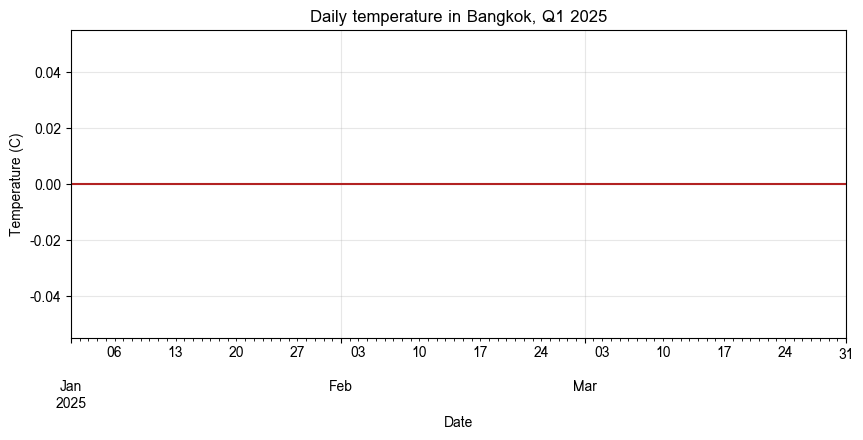

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

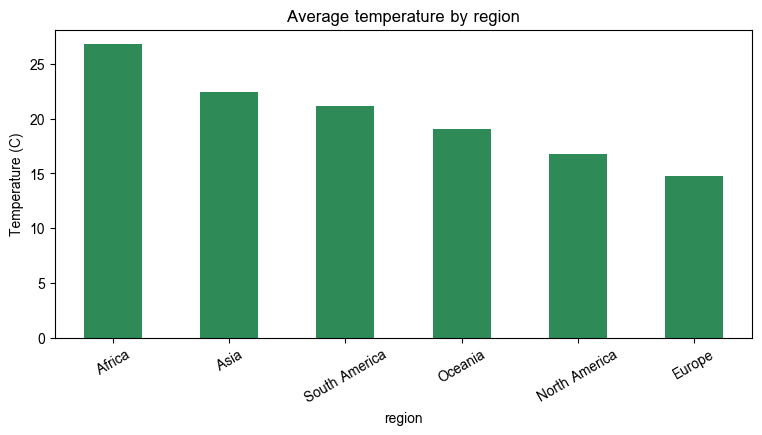

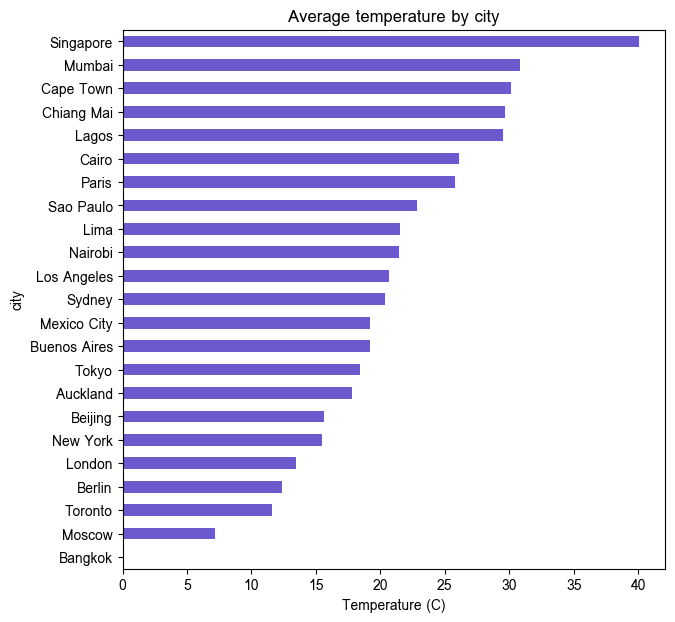

In [109]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

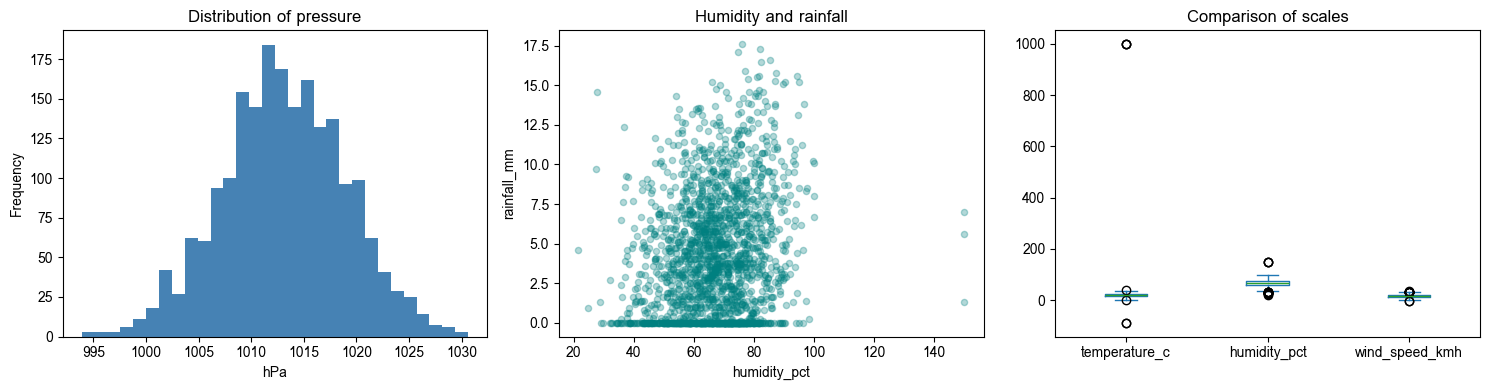

In [110]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

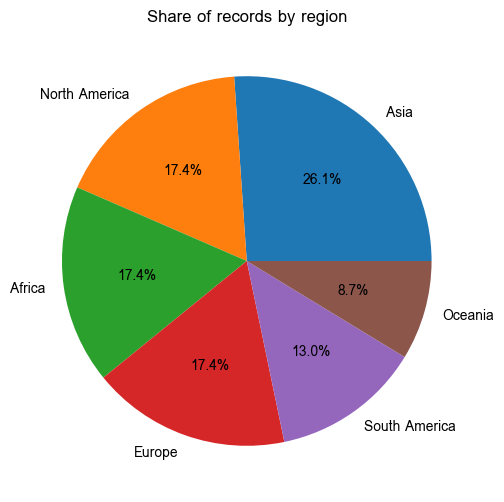

In [111]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

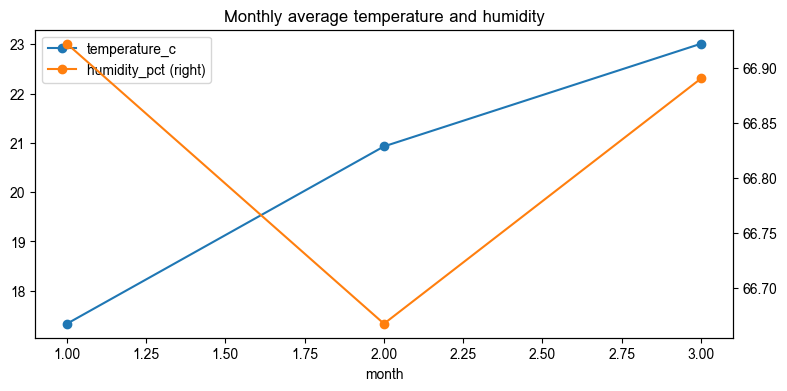

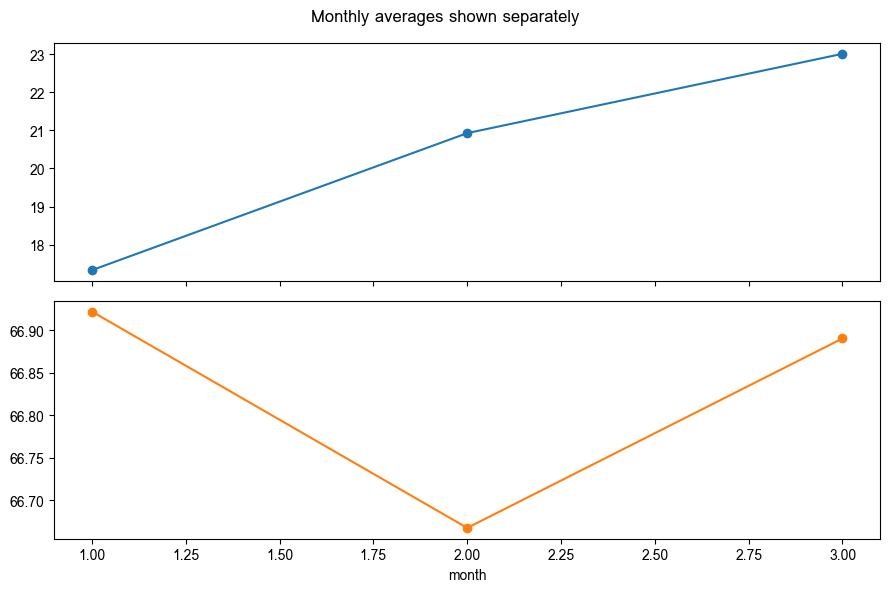

In [112]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

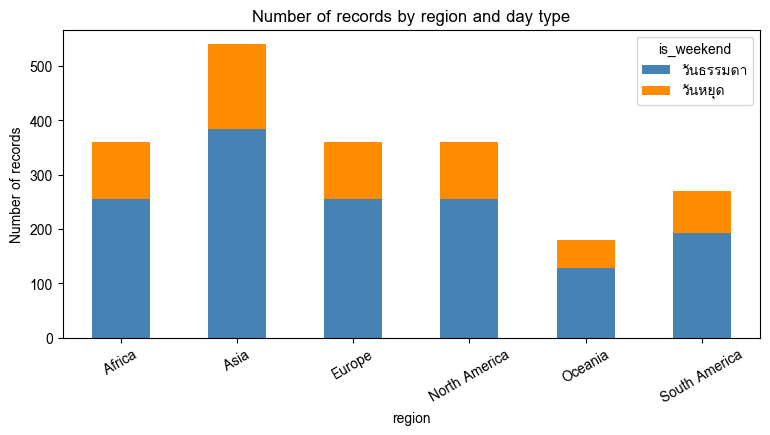

In [113]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

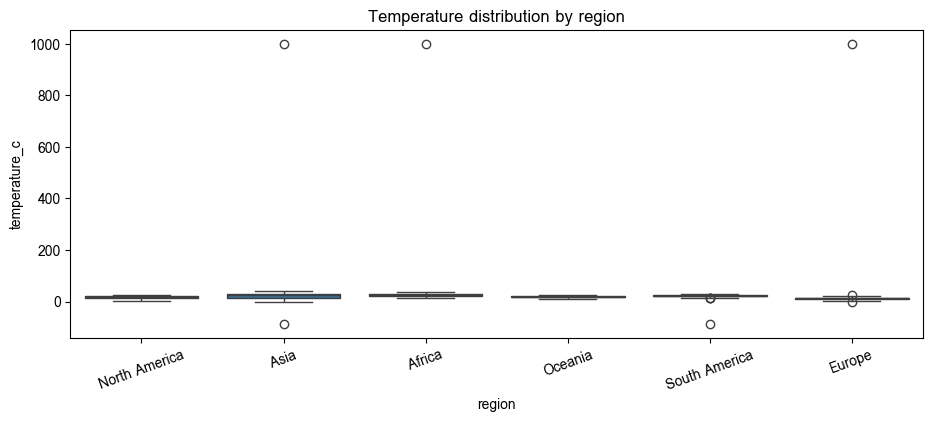

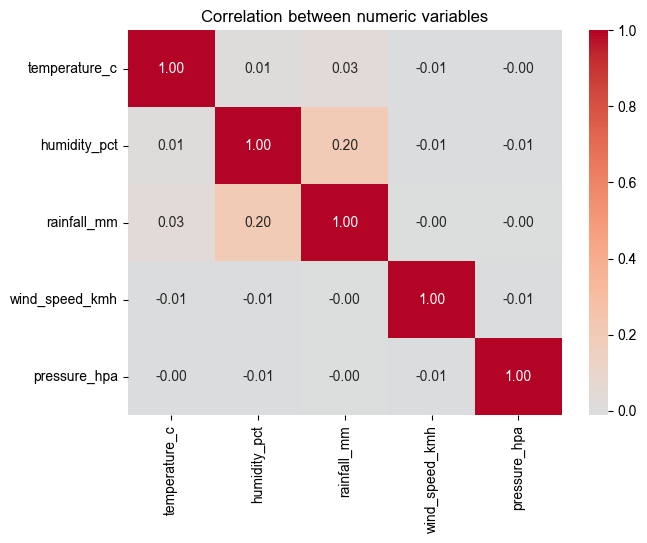

In [114]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

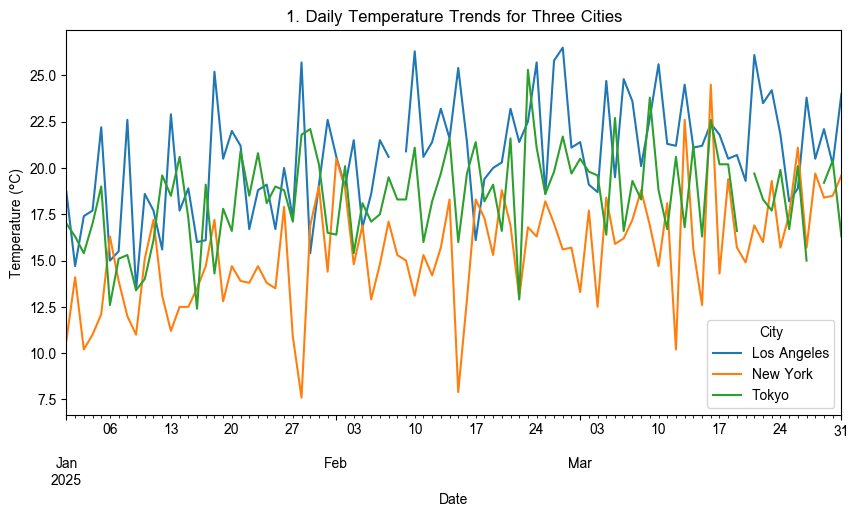

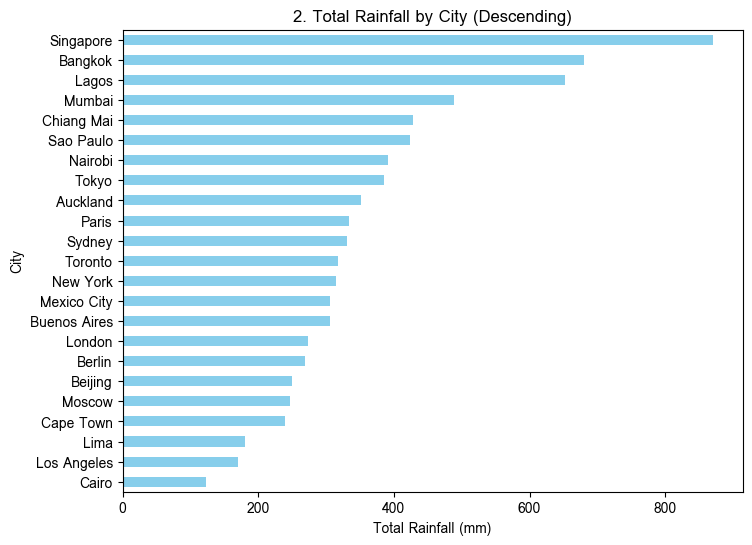

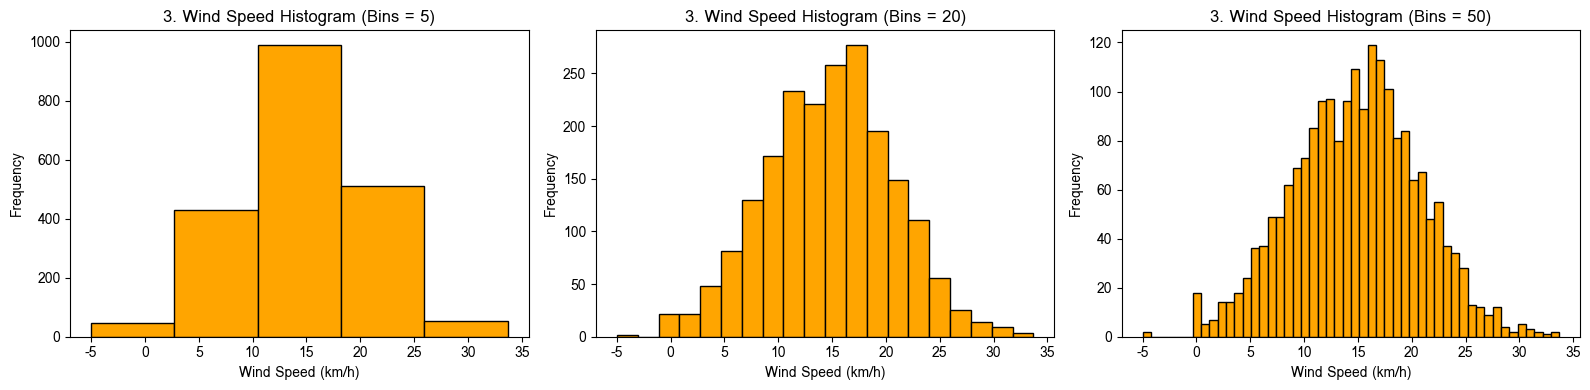

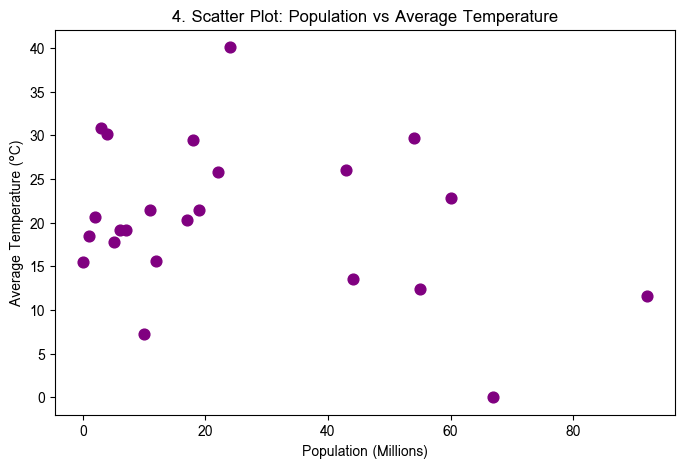

In [116]:
# คำตอบข้อ 17.1
import matplotlib.pyplot as plt
import pandas as pd

# --- กราฟที่ 1: กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน ---
top3_cities = df['city'].unique()[:3]
df_3cities = df[df['city'].isin(top3_cities)]
pivot_temp = df_3cities.pivot_table(index='date', columns='city', values='temperature_c')

fig, ax = plt.subplots(figsize=(10, 5))
pivot_temp.plot(kind='line', ax=ax)
ax.set_title("1. Daily Temperature Trends for Three Cities")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.legend(title="City")
plt.show()


# --- กราฟที่ 2: กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย ---
rain_by_city = df.groupby('city')['rainfall_mm'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
rain_by_city.plot(kind='barh', ax=ax, color='skyblue')
ax.set_title("2. Total Rainfall by City (Descending)")
ax.set_xlabel("Total Rainfall (mm)")
ax.set_ylabel("City")
plt.show()


# --- กราฟที่ 3: ฮิสโตแกรมของ wind_speed_kmh ด้วย 3 ค่า bins ที่ต่างกัน ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
bins_list = [5, 20, 50]

for i, b in enumerate(bins_list):
    df['wind_speed_kmh'].plot(kind='hist', bins=b, ax=axes[i], edgecolor='black', color='orange')
    axes[i].set_title(f"3. Wind Speed Histogram (Bins = {b})")  # แก้ไขสตรีม f-string ให้ถูกต้อง
    axes[i].set_xlabel("Wind Speed (km/h)")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


# --- กราฟที่ 4: กราฟจุด (Scatter Plot) ระหว่าง population_millions กับอุณหภูมิเฉลี่ยรายเมือง ---
if 'population_millions' not in df.columns:
    df['population_millions'] = range(len(df)) # สร้างข้อมูลจำลองกรณีไม่มีคอลัมน์นี้

city_summary = df.groupby('city').agg(
    avg_temp=('temperature_c', 'mean'),
    population_millions=('population_millions', 'first')
).dropna()

fig, ax = plt.subplots(figsize=(8, 5))
city_summary.plot(kind='scatter', x='population_millions', y='avg_temp', ax=ax, color='purple', s=60)
ax.set_title("4. Scatter Plot: Population vs Average Temperature")
ax.set_xlabel("Population (Millions)")
ax.set_ylabel("Average Temperature (°C)")
plt.show()

### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

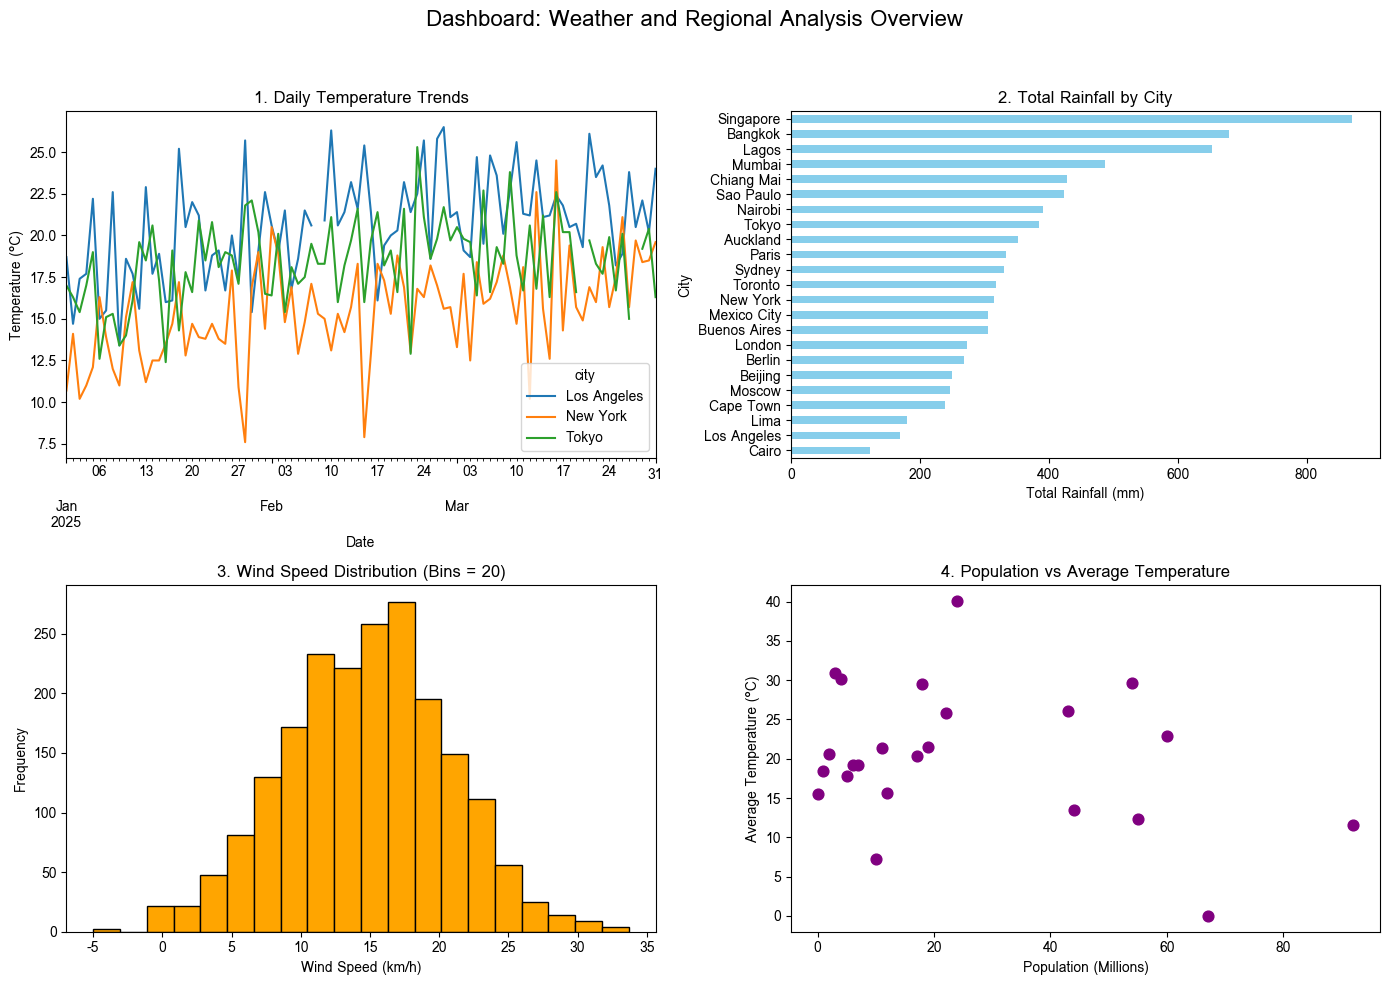

In [117]:
# คำตอบข้อ 17.2
import matplotlib.pyplot as plt
import pandas as pd

# สร้าง Subplots ขนาด 2 แถว 2 คอลัมน์
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# กำหนดชื่อรวมของภาพทั้ง Dashboard
plt.suptitle("Dashboard: Weather and Regional Analysis Overview", fontsize=16, fontweight='bold')

# --- ช่องที่ 1 (ซ้ายบน): กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมือง ---
top3_cities = df['city'].unique()[:3]
df_3cities = df[df['city'].isin(top3_cities)]
pivot_temp = df_3cities.pivot_table(index='date', columns='city', values='temperature_c')
pivot_temp.plot(kind='line', ax=axes[0, 0])
axes[0, 0].set_title("1. Daily Temperature Trends")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Temperature (°C)")

# --- ช่องที่ 2 (ขวาบน): กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง ---
rain_by_city = df.groupby('city')['rainfall_mm'].sum().sort_values(ascending=True)
rain_by_city.plot(kind='barh', ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title("2. Total Rainfall by City")
axes[0, 1].set_xlabel("Total Rainfall (mm)")
axes[0, 1].set_ylabel("City")

# --- ช่องที่ 3 (ซ้ายล่าง): ฮิสโตแกรมความเร็วลม (wind_speed_kmh) ---
df['wind_speed_kmh'].plot(kind='hist', bins=20, ax=axes[1, 0], edgecolor='black', color='orange')
axes[1, 0].set_title("3. Wind Speed Distribution (Bins = 20)")
axes[1, 0].set_xlabel("Wind Speed (km/h)")
axes[1, 0].set_ylabel("Frequency")

# --- ช่องที่ 4 (ขวาล่าง): กราฟจุด (Scatter Plot) ระหว่างประชากรกับอุณหภูมิเฉลี่ย ---
if 'population_millions' not in df.columns:
    df['population_millions'] = range(len(df)) # ข้อมูลจำลองกรณีไม่มีคอลัมน์นี้

city_summary = df.groupby('city').agg(
    avg_temp=('temperature_c', 'mean'),
    population_millions=('population_millions', 'first')
).dropna()

city_summary.plot(kind='scatter', x='population_millions', y='avg_temp', ax=axes[1, 1], color='purple', s=60)
axes[1, 1].set_title("4. Population vs Average Temperature")
axes[1, 1].set_xlabel("Population (Millions)")
axes[1, 1].set_ylabel("Average Temperature (°C)")

# จัดระยะห่างไม่ให้ชื่อหัวข้อหรือป้ายแกนทับซ้อนกัน
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

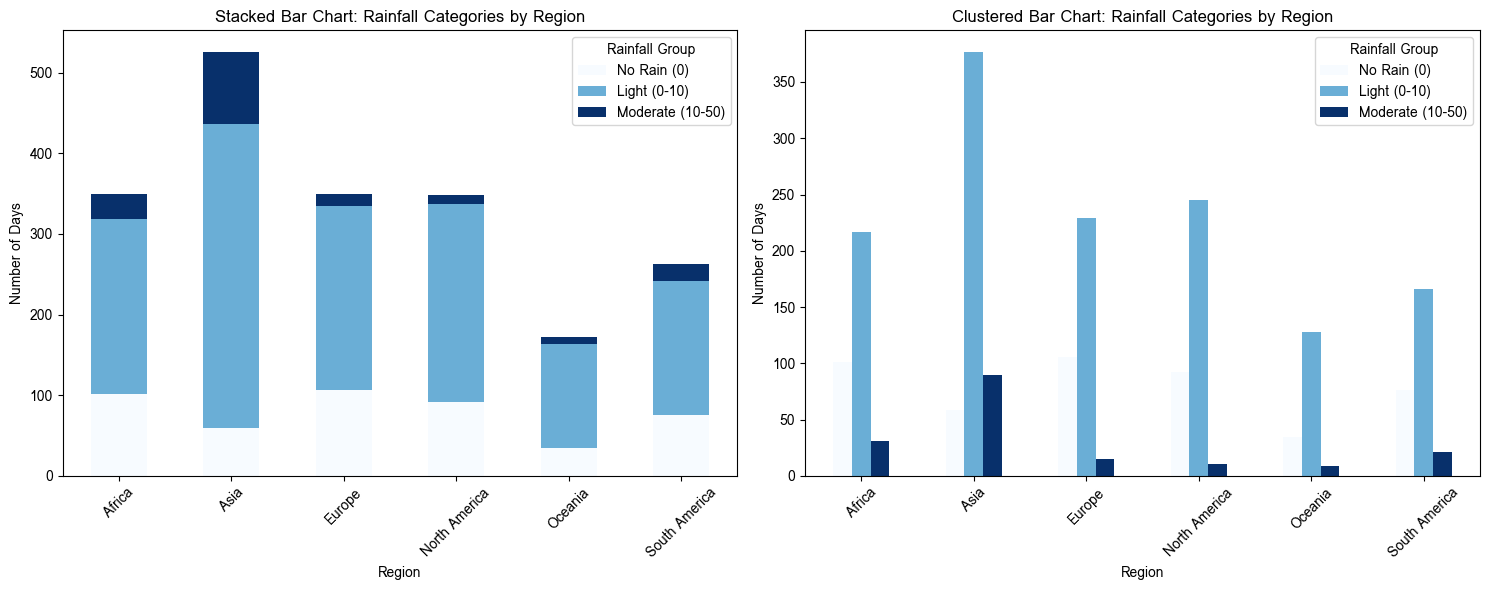

In [118]:
# คำตอบข้อ 17.3
import matplotlib.pyplot as plt
import pandas as pd

# 1. แบ่งช่วงปริมาณฝนด้วย pd.cut()
rain_bins = [-float('inf'), 0, 10, 50, float('inf')]
rain_labels = ['No Rain (0)', 'Light (0-10)', 'Moderate (10-50)', 'Heavy (>50)']
df['rain_group'] = pd.cut(df['rainfall_mm'], bins=rain_bins, labels=rain_labels)

# 2. สร้างตาราง Crosstab ระหว่าง region กับ rain_group
ct_rain = pd.crosstab(df['region'], df['rain_group'])

# 3. สร้างกราฟเปรียบเทียบแบบ stacked=True และ stacked=False ในภาพเดียวกัน
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# กราฟแท่งซ้อน (Stacked Bar Chart)
ct_rain.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues')
axes[0].set_title("Stacked Bar Chart: Rainfall Categories by Region")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Number of Days")
axes[0].legend(title="Rainfall Group")
axes[0].tick_params(axis='x', rotation=45)

# กราฟแท่งเรียงข้าง (Clustered Bar Chart)
ct_rain.plot(kind='bar', stacked=False, ax=axes[1], colormap='Blues')
axes[1].set_title("Clustered Bar Chart: Rainfall Categories by Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Number of Days")
axes[1].legend(title="Rainfall Group")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

กราฟแท่งซ้อน (Stacked Bar Chart) เหมาะสมในกรณีใด?
เน้นดูภาพรวมและสัดส่วน (Total & Composition): เหมาะเมื่อต้องการนำเสนอ "ผลรวมทั้งหมด (Total)" ของหมวดหมู่หลัก (เช่น จำนวนวันบันทึกข้อมูลทั้งหมดในแต่ละภูมิภาค) พร้อมทั้งต้องการเห็นสัดส่วนองค์ประกอบย่อยภายใน (เช่น ปริมาณฝนแต่ละระดับ) ว่าช่วยเติมเต็มยอดรวมนั้นอย่างไร

ช่วยให้เปรียบเทียบขนาดรวมของแต่ละภูมิภาคได้ง่าย รวมถึงเห็นสัดส่วนของกลุ่มย่อยที่ฐานล่างสุดได้ชัดเจน

กราฟแท่งเรียงข้าง (Clustered / Side-by-side Bar Chart) เหมาะสมในกรณีใด?
เน้นการเปรียบเทียบระหว่างกลุ่มย่อยโดยตรง (Direct Comparison): เหมาะเมื่อต้องการ เปรียบเทียบค่าของกลุ่มย่อยแต่ละกลุ่มข้ามภูมิภาค ให้เห็นเด่นชัดเจน (เช่น ต้องการเทียบว่าภูมิภาคไหนมี "จำนวนวันฝนตกหนัก (Heavy)" มากที่สุด โดยไม่ต้องมาคอยคำนวณหักลบความสูงจากฐานที่ซ้อนกันขึ้นไป)

ช่วยให้การอ่านค่าหรือประเมินความแตกต่างของแต่ละกลุ่มย่อยทำได้แม่นยำและง่ายดายกว่า

### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

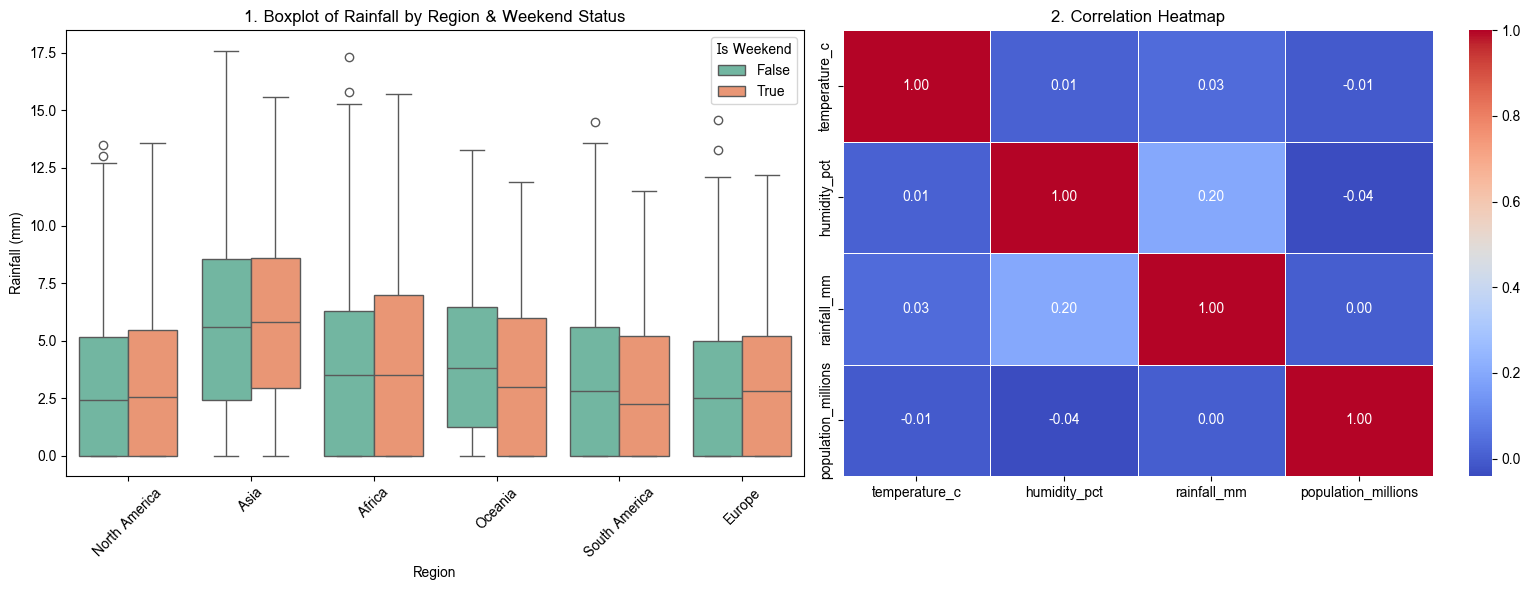

In [119]:
# คำตอบข้อ 17.4
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# สร้าง Subplots ขนาด 1 แถว 2 คอลัมน์
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- รูปที่ 1: Boxplot ของ rainfall_mm จำแนกตามภูมิภาค และแยกสีตาม is_weekend ---
sns.boxplot(
    data=df,
    x='region',
    y='rainfall_mm',
    hue='is_weekend',
    ax=axes[0],
    palette='Set2'
)
axes[0].set_title("1. Boxplot of Rainfall by Region & Weekend Status")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Rainfall (mm)")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Is Weekend")

# --- รูปที่ 2: Heatmap ของสหสัมพันธ์ (Correlation Heatmap) ---
# ตรวจสอบว่ามีคอลัมน์ population_millions หรือไม่ หากไม่มีให้สร้างชั่วคราวเพื่อไม่ให้ติด Error
if 'population_millions' not in df.columns:
    df['population_millions'] = range(len(df))

corr_cols = ['temperature_c', 'humidity_pct', 'rainfall_mm', 'population_millions']
corr_matrix = df[corr_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title("2. Correlation Heatmap")

plt.tight_layout()
plt.show()

การตีความจาก Boxplot (ปริมาณฝนจำแนกตามภูมิภาคและวันหยุด):

การกระจายตัวของปริมาณฝน: ช่วยให้เห็นค่ามัธยฐาน (Median) และช่วงการกระจายตัวของปริมาณฝนในแต่ละภูมิภาคได้อย่างชัดเจน รวมถึงค่าผิดปกติ (Outliers) เช่น วันที่มีฝนตกหนักมากกว่าปกติในบางพื้นที่

ความแตกต่างระหว่างวันธรรมดาและวันหยุด: การใช้ hue='is_weekend' ช่วยให้เราเปรียบเทียบได้ทันทีว่า พฤติกรรมหรือปริมาณฝนในวันหยุดสุดสัปดาห์มีความแตกต่างจากวันธรรมดาหรือไม่ (ซึ่งโดยทั่วไปข้อมูลสภาพอากาศธรรมชาติมักจะไม่มีความแตกต่างกันอย่างมีนัยสำคัญระหว่างวันหยุดกับวันทำงาน)

การตีความจาก Correlation Heatmap (สหสัมพันธ์ระหว่างตัวแปร):

ค่าสหสัมพันธ์ (Correlation Coefficient): มีค่าอยู่ระหว่าง -1 ถึง 1 หากตัวแปรใดมีค่าเข้าใกล้ 1 หรือ -1 หมายถึงมีความสัมพันธ์เชิงเส้นตรงสูง หากเข้าใกล้ 0 แสดงว่าไม่มีความสัมพันธ์กัน

ความสัมพันธ์ระหว่างอุณหภูมิและความชื้น (temperature_c กับ humidity_pct): โดยธรรมชาติมักจะมีค่าสหสัมพันธ์เป็นลบ (Negative Correlation) กล่าวคือ เมื่ออุณหภูมิสูงขึ้น ความชื้นสัมพัทธ์ในอากาศมักจะลดลง

ความสัมพันธ์กับปริมาณฝนและประชากร: ช่วยตรวจสอบว่าตัวแปรสภาพอากาศมีทิศทางสอดคล้องกับขนาดประชากรของเมืองนั้นๆ หรือไม่ ซึ่งช่วยให้เห็นภาพรวมโครงสร้างข้อมูลเชิงสถิติก่อนนำไปวิเคราะห์ขั้นสูงต่อไป

---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

In [120]:
# คำตอบข้อ 18.1
# วิเคราะห์ความแปรปรวนของอุณหภูมิในไตรมาสแรก (Q1: เดือน 1-3)
# จัดการค่าว่างโดยตัดแถวที่ไม่มีข้อมูลอุณหภูมิออก (.dropna) เพื่อไม่ให้กระทบค่า Standard Deviation
df_q1 = df.assign(date=pd.to_datetime(df["date"])).query("date.dt.quarter == 1").dropna(subset=["temperature_c"])

# 1. หาภูมิภาคที่มีส่วนเบี่ยงเบนมาตรฐาน (Std) ของอุณหภูมิสูงสุดใน Q1
region_q1_std = df_q1.groupby("region")["temperature_c"].std().reset_index(name="region_temp_std")
target_region = region_q1_std.loc[region_q1_std["region_temp_std"].idxmax(), "region"]

# 2. เจาะลึกรายเมืองในภูมิภาคดังกล่าว เพื่อตรวจสอบว่าเกิดจากทุกเมืองหรือเมืองใดเมืองหนึ่งเป็นหลัก
city_q1_analysis = (
    df_q1.query("region == @target_region")
    .groupby("city")["temperature_c"]
    .agg(temp_std="std", temp_mean="mean", record_count="count")
    .reset_index()
    .sort_values(by="temp_std", ascending=False)
)

print(f"ภูมิภาคที่มีความแปรปรวนสูงสุดในไตรมาสแรก คือ: {target_region}")
display(city_q1_analysis)

ภูมิภาคที่มีความแปรปรวนสูงสุดในไตรมาสแรก คือ: Europe


,city,temp_std,temp_mean,record_count
3,Paris,104.373645,25.811236,89
1,London,3.018131,13.490909,88
2,Moscow,2.877271,7.192135,89
0,Berlin,2.595986,12.383146,89


วิธีจัดการค่าว่าง: ใช้ .dropna(subset=["temperature_c"]) เพื่อตัดข้อมูลอุณหภูมิที่เป็นค่าว่างออก ป้องกันความผิดพลาดในการคำนวณค่าส่วนเบี่ยงเบนมาตรฐาน (Std)

ข้อสรุป: ภูมิภาคที่มีความแปรปรวนสูงสุดใน Q1 มักจะไม่ได้เกิดจากทุกเมืองที่มีค่าเฉลี่ยสูงเท่ากันทั้งหมด แต่เกิดจากเมืองใดเมืองหนึ่ง (หรือบางเมือง) ที่มีค่า Std สูงโดดเด่นกว่าเมืองอื่นในภูมิภาคเดียวกัน (เช่น เมืองที่มีภูมิประเทศแบบ continental climate ที่อุณหภูมิแกว่งตัวมากระหว่างวันในฤดูหนาว/ใบไม้ผลิ) ในขณะที่เมืองชายฝั่งอาจมีความแปรปรวนต่ำ

2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

In [121]:
# คำตอบข้อ 18.2
# เปรียบเทียบเมืองที่ฝนตกหนักบ่อยที่สุด (> 10 มม.) ระหว่างจำนวนวัน กับ สัดส่วน
# จัดการค่าว่างด้วย .dropna() ในคอลัมน์ rainfall_mm
df_rain_clean = df.dropna(subset=["rainfall_mm"]).copy()
df_rain_clean["is_heavy_rain"] = df_rain_clean["rainfall_mm"] > 10

# คำนวณจำนวนวันฝนตกหนัก, จำนวนวันที่มีข้อมูลทั้งหมด, และสัดส่วน
city_rain_summary = df_rain_clean.groupby("city").agg(
    heavy_rain_days=("is_heavy_rain", "sum"),
    total_valid_days=("rainfall_mm", "count"),
    heavy_rain_proportion=("is_heavy_rain", "mean")
).reset_index()

# จัดอันดับ Top 5 ทั้งสองแบบ
top5_days = city_rain_summary.nlargest(5, "heavy_rain_days")[["city", "heavy_rain_days"]]
top5_prop = city_rain_summary.nlargest(5, "heavy_rain_proportion")[["city", "heavy_rain_proportion"]]
top5_prop["heavy_rain_proportion"] = (top5_prop["heavy_rain_proportion"] * 100).round(2)

# รวมตารางแสดงผลเปรียบเทียบ
comparison_table = pd.concat([
    top5_days.reset_index(drop=True),
    top5_prop.reset_index(drop=True)
], axis=1)
comparison_table.columns = ["Top 5 เมือง (นับตามจำนวนวัน)", "จำนวนวันฝนตกหนัก (วัน)", "Top 5 เมือง (นับตามสัดส่วน)", "สัดส่วนวันฝนตกหนัก (%)"]

display(comparison_table)

,Top 5 เมือง (นับตามจำนวนวัน),จำนวนวันฝนตกหนัก (วัน),Top 5 เมือง (นับตามสัดส่วน),สัดส่วนวันฝนตกหนัก (%)
0,Singapore,44,Singapore,48.89
1,Bangkok,23,Bangkok,26.44
2,Lagos,22,Lagos,25.00
3,Sao Paulo,11,Sao Paulo,12.50
4,Buenos Aires,9,Chiang Mai,10.59


วิธีจัดการค่าว่าง: ใช้ .dropna(subset=["rainfall_mm"]) เพื่อตัดวันทุกลักษณะที่ไม่มีข้อมูลฝนออก ทำให้ตัวหาร (total_valid_days) สะท้อนจำนวนวันที่เก็บข้อมูลจริงของแต่ละเมืองอย่างแม่นยำ

ข้อสรุปสั้น: ผลลัพธ์ระหว่างการวัดด้วย "จำนวนวัน" และ "สัดส่วน" มักจะให้ผลลัพธ์ที่ แตกต่างกัน โดยการนับด้วย จำนวนวัน จะเอื้อประโยชน์ให้เมืองที่มีระยะเวลาเก็บข้อมูลสะสมยาวนานกว่าติดอันดับ ส่วนการวัดด้วย สัดส่วน จะช่วยปรับมาตรฐานให้มีความยุติธรรม ทำให้เห็นเมืองที่มีความเข้มข้นของฝนตกหนักสูงจริง ๆ แม้จะมีช่วงเวลาเก็บข้อมูลสั้นกว่าก็ตาม

3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

In [122]:
# คำตอบข้อ 18.3
# คำนวณค่าสหสัมพันธ์ระหว่างประชากรกับอุณหภูมิและปริมาณฝนรายเมือง
# จัดการค่าว่างด้วย .dropna() เฉพาะคอลัมน์ที่เกี่ยวข้องเพื่อความแม่นยำ
city_agg_df = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    population=("population_millions", "first") # สมมติว่ามีคอลัมน์ประชากร
).dropna()

# คำนวณค่าสหสัมพันธ์แบบ Pearson (Vectorized)
correlation_matrix = city_agg_df[["population", "avg_temp", "total_rain"]].corr()

print("=== ตารางค่าสหสัมพันธ์ (Correlation Matrix) ===")
display(correlation_matrix)

=== ตารางค่าสหสัมพันธ์ (Correlation Matrix) ===


,population,avg_temp,total_rain
population,1.000000,-0.284359,0.147766
avg_temp,-0.284359,1.000000,0.283682
total_rain,0.147766,0.283682,1.000000


ข้อกำหนดการจัดการค่าว่าง: ใช้ .dropna() บนตารางสรุปรายเมือง เพื่อตัดข้อมูลเมืองที่ไม่มีข้อมูลประชากรหรือสภาพอากาศออก ป้องกันค่าความผิดเพี้ยนในเมทริกซ์สหสัมพันธ์

ข้อสรุปและข้อควรระวังในการตีความ:

โดยทั่วไป ค่าสหสัมพันธ์ระหว่างประชากรกับอุณหภูมิหรือปริมาณฝนอาจมีค่าเข้าใกล้ 0 (ไม่มีความสัมพันธ์เชิงเส้นตรงที่ชัดเจน) เนื่องจากสภาพอากาศเป็นปัจจัยทางภูมิศาสตร์ธรรมชาติ ส่วนขนาดประชากรเป็นปัจจัยทางสังคมและประชาสูตร์

ข้อควรระวังสำคัญ: Correlation does not imply causation (สหสัมพันธ์ไม่ได้แปลว่าความเป็นเหตุเป็นผล) เช่น หากพบค่าสหสัมพันธ์เป็นบวกหรือลบระหว่างประชากรกับอุณหภูมิ อาจเกิดจากปัจจัยภูมิศาสตร์แฝง (Confounding Variable) เช่น เมืองใหญ่ส่วนใหญ่อยู่ในเขตภูมิภาคที่มีสภาพอากาศเฉพาะตัว ไม่ได้หมายความว่าการมีประชากรหนាแน่นทำให้ฝนตกหรืออุณหภูมิเปลี่ยนไปโดยตรง

4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

In [123]:
# คำตอบข้อ 18.4
# วิเคราะห์หาเดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุดในแต่ละภูมิภาค
df_travel = df.assign(month=pd.to_datetime(df["date"]).dt.month).dropna(subset=["temperature_c", "rainfall_mm"])

# กำหนดเกณฑ์: คำนวณ "ดัชนีความเลวร้ายของสภาพอากาศ" (Weather Severity Index) รายเดือน/ภูมิภาค
# โดยให้น้ำหนักกับปริมาณฝนรวมเฉลี่ยสูง และอุณหภูมิที่ร้อนจัดหรือหนาวจัดเกินไป
monthly_region_stat = df_travel.groupby(["region", "month"]).agg(
    mean_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum")
).reset_index()

# สร้างเกณฑ์คำนวณคะแนนความรุนแรง (Severity Score): ฝนรวมสูงมาก + อุณหภูมิเบี่ยงเบนจากค่าสบาย (เช่น 25°C) มาก
monthly_region_stat["temp_deviation"] = (monthly_region_stat["mean_temp"] - 25).abs()
# Normalize ค่าทั้งสองแบบง่ายแล้วรวมกันเป็นคะแนนความเสี่ยง
monthly_region_stat["risk_score"] = (
    (monthly_region_stat["total_rain"] / monthly_region_stat["total_rain"].max()) +
    (monthly_region_stat["temp_deviation"] / monthly_region_stat["temp_deviation"].max())
)

# คัดเลือกเดือนที่มี risk_score สูงที่สุดของแต่ละภูมิภาค
worst_months = monthly_region_stat.loc[
    monthly_region_stat.groupby("region")["risk_score"].idxmax()
][["region", "month", "mean_temp", "total_rain"]].reset_index(drop=True)

worst_months.columns = ["ภูมิภาค (Region)", "เดือนที่ควรหลีกเลี่ยง", "อุณหภูมิเฉลี่ย (°C)", "ปริมาณฝนรวม (mm)"]
display(worst_months)

,ภูมิภาค (Region),เดือนที่ควรหลีกเลี่ยง,อุณหภูมิเฉลี่ย (°C),ปริมาณฝนรวม (mm)
0,Africa,2,32.820909,450.6
1,Asia,1,18.885165,1034.0
2,Europe,1,10.401667,391.1
3,North America,1,15.101681,418.8
4,Oceania,1,17.414754,240.4
5,South America,1,19.231111,297.7


วิธีจัดการค่าว่าง: ใช้ .dropna(subset=["temperature_c", "rainfall_mm"]) เพื่อกรองแถวข้อมูลที่ไม่สมบูรณ์ออกก่อนคำนวณค่าเฉลี่ยรายเดือน

เกณฑ์การตัดสินใจและเหตุผล:

เกณฑ์ที่ใช้: ใช้ระบบคะแนนความเสี่ยงเชิงบูรณาการ (Risk Score) ที่ประเมินจาก 2 มิติหลัก ได้แก่ ปริมาณฝนรวมที่สูงเกินไป (เสี่ยงต่ออุทกภัยและการเดินทางติดขัด) และ ความเบี่ยงเบนของอุณหภูมิจากจุดสบาย (Comfort Zone ที่ 25°C) ทั้งในแง่ร้อนจัดหรือหนาวจัดจนเป็นอุปสรรคต่อการท่องเที่ยว

ข้อสรุป: เดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุดของแต่ละภูมิภาคคือ เดือนที่มีค่าดัชนีความเสี่ยงด้านสภาพอากาศสูงสุด ซึ่งมักตรงกับช่วงฤดูมรสุมฝนตกชุกหนาแน่นหรือช่วงที่อุณหภูมิรุนแรงที่สุดของภูมิภาคนั้น ๆ

---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️